# Modelos para Dados Tabulares em 2025 — um benchmark multicritério
### Acompanhamento Individual 1 · João Gabriel de Araújo Vasconcelos

**11 modelos × 18 datasets (OpenML)** · nested cross-validation (5×3) · tuning bayesiano (Optuna TPE) ·
testes estatísticos frequentistas **e** bayesianos · GPU única (RTX 5080).

> **Tese da apresentação.** O ditado *"em dados tabulares, GBDT sempre vence"* foi formado antes da
> geração 2024–2025 de deep learning tabular (TabM, RealMLP, STab) e dos *foundation models* (TabPFN v2).
> Re-testamos com rigor — e mostramos que, **quando a acurácia empata, a decisão migra para outros eixos**
> (custo, latência, robustez, estrutura da tarefa). A contribuição é tornar essa migração rigorosa,
> multi-eixo e acionável (uma **matriz de decisão + flowchart**).

*Este notebook é autocontido: as figuras estão embutidas; o código que gera os números-chave está visível.*

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
FIG = '../results/figures'

def show(name, caption=None, width=820):
    p = f'{FIG}/{name}'
    display(Image(filename=p, width=width))
    if caption:
        display(Markdown(f'*{caption}*'))

print('presentation helpers ready')

presentation helpers ready


---
## 1. Os 11 modelos — proveniência e escolhas de implementação

Um ponto metodológico importante (e honesto): **nem todo modelo veio "de graça" de uma biblioteca.**
A tabela abaixo registra, para cada modelo, **de onde** veio a implementação — biblioteca oficial,
biblioteca da comunidade, ou **implementação própria** (reimplementada a partir do artigo / repositório
original). Isso afeta a interpretação dos resultados e foi parte significativa do trabalho de engenharia.

| # | Modelo | Família | Ano | Proveniência da implementação |
|---|--------|---------|-----|-------------------------------|
| 1 | **XGBoost** | GBDT | 2016 | Biblioteca oficial `xgboost` |
| 2 | **LightGBM** | GBDT | 2017 | Biblioteca oficial `lightgbm` |
| 3 | **CatBoost** | GBDT | 2018 | Biblioteca oficial `catboost` (handling categórico nativo) |
| 4 | **TabPFN v2.5** | Foundation | 2025 | Pacote oficial `tabpfn` (≥6.0) |
| 5 | **RealMLP** | DL (MLP) | 2024 | Pacote oficial `pytabkit` (Holzmüller et al., NeurIPS 2024) |
| 6 | **TabM** | DL (MLP) | 2025 | Pacote oficial `tabm` (Gorishniy et al., ICLR 2025) |
| 7 | **TabNet** | DL (attn+seleção) | 2021 | Biblioteca da comunidade `pytorch-tabnet` |
| 8 | **MLP** | DL (baseline) | — | **Implementação própria** (PyTorch): Linear→BatchNorm→ReLU→Dropout |
| 9 | **FT-Transformer** | DL (attention) | 2021 | **Implementação própria** da arquitetura + loop de treino custom |
| 10 | **SAINT** | DL (attention dupla) | 2021 | **Reimplementação própria a partir do artigo** (Somepalli et al., 2021) |
| 11 | **STab** | DL (competição estocástica) | 2024 | **Reimplementação própria a partir do artigo + repo de referência** (Voskou et al., ICML 2024 W) |

**Resumo da proveniência:** 6 de bibliotecas oficiais (3 GBDT + TabPFN + RealMLP + TabM),
1 da comunidade (TabNet), e **4 implementações próprias em PyTorch** — destas, MLP é baseline,
FT-Transformer é a arquitetura reimplementada, e **SAINT e STab foram reescritos seguindo os papers**
(STab também conferindo o repositório de referência), por não haver pacote oficial maduro.

**Por que esses 11 / por que DL super-representado (7):** a família DL concentra a maior diversidade de
*viés indutivo* — baseados em atenção (FT-Transformer, SAINT, STab), baseados em MLP (MLP, RealMLP, TabM),
e atenção + seleção de features (TabNet). GBDTs (3) são o padrão de mercado; TabPFN (1) é o novo paradigma
*zero-shot*. Cobrir as três famílias é o que torna o estudo um mapa do estado da arte, não um duelo.

### 1.1 Escolhas de arquitetura / implementação que importam

Estas decisões afetam a *justiça* da comparação e foram tomadas explicitamente:

- **Pré-processamento por família** (cada família recebe o input no formato que espera):
  - **GBDT** — *ordinal encoding* + imputação por mediana; **CatBoost** recebe os índices das colunas
    categóricas e usa seu *handling* nativo.
  - **Deep learning** — *standardização* dos numéricos + *one-hot* dos categóricos, com **teto de
    cardinalidade (max 50 categorias)**. Esse teto foi necessário: sem ele, `amazon_employee` explodia
    para ~6.900 colunas e estourava a memória da GPU nos modelos de atenção.
  - **TabPFN** — ordinal; normaliza internamente; **subamostra para 50K** (limite nativo da v2.5) e usa
    um *ensemble* de 4 subamostras para datasets maiores; inferência em *batches* (predição é cara).
- **STab** — usa **64 amostras de *Bayesian averaging*** na avaliação final (8 durante o tuning, por
  custo); ativação **LWTA (Local Winner-Takes-All)** com relaxação Gumbel-Softmax.
- **Treino DL** — máx. 200 épocas, *early stopping* (paciência 20), batch 256, Adam.
- **Robustez de execução** — *cap* de 100K amostras antes do split; redução automática de *batch size*
  em OOM + isolamento por subprocesso (um config grande não derruba a fila inteira).

---
## 2. Protocolo experimental

O esqueleto é uma **validação cruzada aninhada (nested CV)**: o laço externo *mede* o modelo de forma
honesta; o laço interno *escolhe* os hiperparâmetros — sem nunca olhar o conjunto de teste. Abaixo,
um esquema do pipeline ponta-a-ponta.

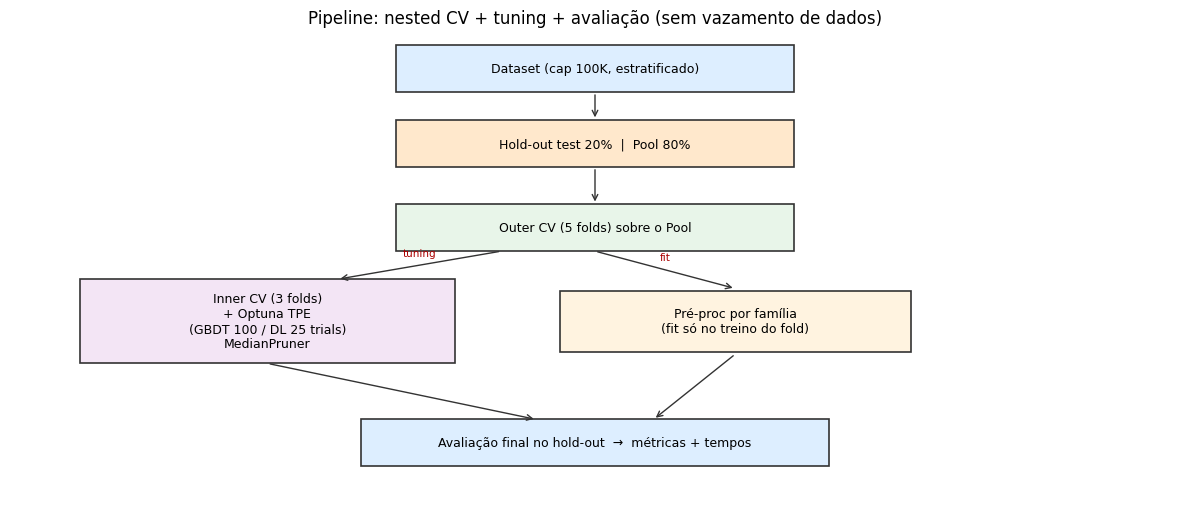

In [2]:
# Esquema do protocolo (desenhado, não é uma figura externa)
fig, ax = plt.subplots(figsize=(12, 5.2)); ax.axis('off')
def b(x,y,t,c='#eef',w=0.2,h=0.1):
    ax.add_patch(plt.Rectangle((x-w/2,y-h/2),w,h,fc=c,ec='#333',lw=1.2))
    ax.text(x,y,t,ha='center',va='center',fontsize=9)
def ar(x1,y1,x2,y2,lbl=''):
    ax.annotate('',(x2,y2),(x1,y1),arrowprops=dict(arrowstyle='->',color='#333'))
    if lbl: ax.text((x1+x2)/2,(y1+y2)/2+0.02,lbl,fontsize=7.5,color='#a00',ha='center')
b(0.5,0.92,'Dataset (cap 100K, estratificado)','#ddeeff',0.34,0.1)
b(0.5,0.76,'Hold-out test 20%  |  Pool 80%','#ffe8cc',0.34,0.1); ar(0.5,0.87,0.5,0.81)
b(0.5,0.58,'Outer CV (5 folds) sobre o Pool','#e8f5e9',0.34,0.1); ar(0.5,0.71,0.5,0.63)
b(0.22,0.38,'Inner CV (3 folds)\n+ Optuna TPE\n(GBDT 100 / DL 25 trials)\nMedianPruner','#f3e5f5',0.32,0.18)
b(0.62,0.38,'Pré-proc por família\n(fit só no treino do fold)','#fff3e0',0.3,0.13)
ar(0.42,0.53,0.28,0.47,'tuning'); ar(0.5,0.53,0.62,0.45,'fit')
b(0.5,0.12,'Avaliação final no hold-out  →  métricas + tempos','#ddeeff',0.4,0.1)
ar(0.22,0.29,0.45,0.17); ar(0.62,0.31,0.55,0.17)
ax.set_title('Pipeline: nested CV + tuning + avaliação (sem vazamento de dados)', fontsize=12)
plt.tight_layout(); plt.show()

**Configuração** (de `configs/experiment.yaml`):
seed=42 · test_size=0.2 · outer_folds=5 · inner_folds=3 · TPE com **MedianPruner** ·
**GBDT = 100 trials, DL/FM = 25 trials** (o custo por trial do DL é ~4× maior, daí o orçamento menor).

**Métricas** (primária / secundárias):
binária → **ROC-AUC** / acc, F1, log-loss, **KS** · multiclasse → **log-loss** / acc, F1-macro/weighted ·
regressão → **RMSE** / MAE, R². Tempos coletados: tuning, treino final, e **latência de inferência**.

**Hiperparâmetros tunados por modelo** (nº de HPs): xgboost 8 · lightgbm 9 · catboost 6 ·
ft_transformer 9 · tabnet 7 · saint 7 · mlp 5 · realmlp 9 · stab 8 · tabm 7 · **tabpfn 0 (zero-shot)**.

**Testes estatísticos:** Friedman (omnibus) → Nemenyi + Wilcoxon (Holm) + diagramas de *critical difference*;
Cohen's d (tamanho de efeito); ICs bootstrap; e — adicionado nesta fase — **teste bayesiano signed-rank
com ROPE** (probabilidade de superioridade, não só significância).

---
## 3. Os 18 datasets

10 binárias · 3 multiclasse · 5 regressão · de **1K a 581K** amostras · numéricos, mistos e categóricos.

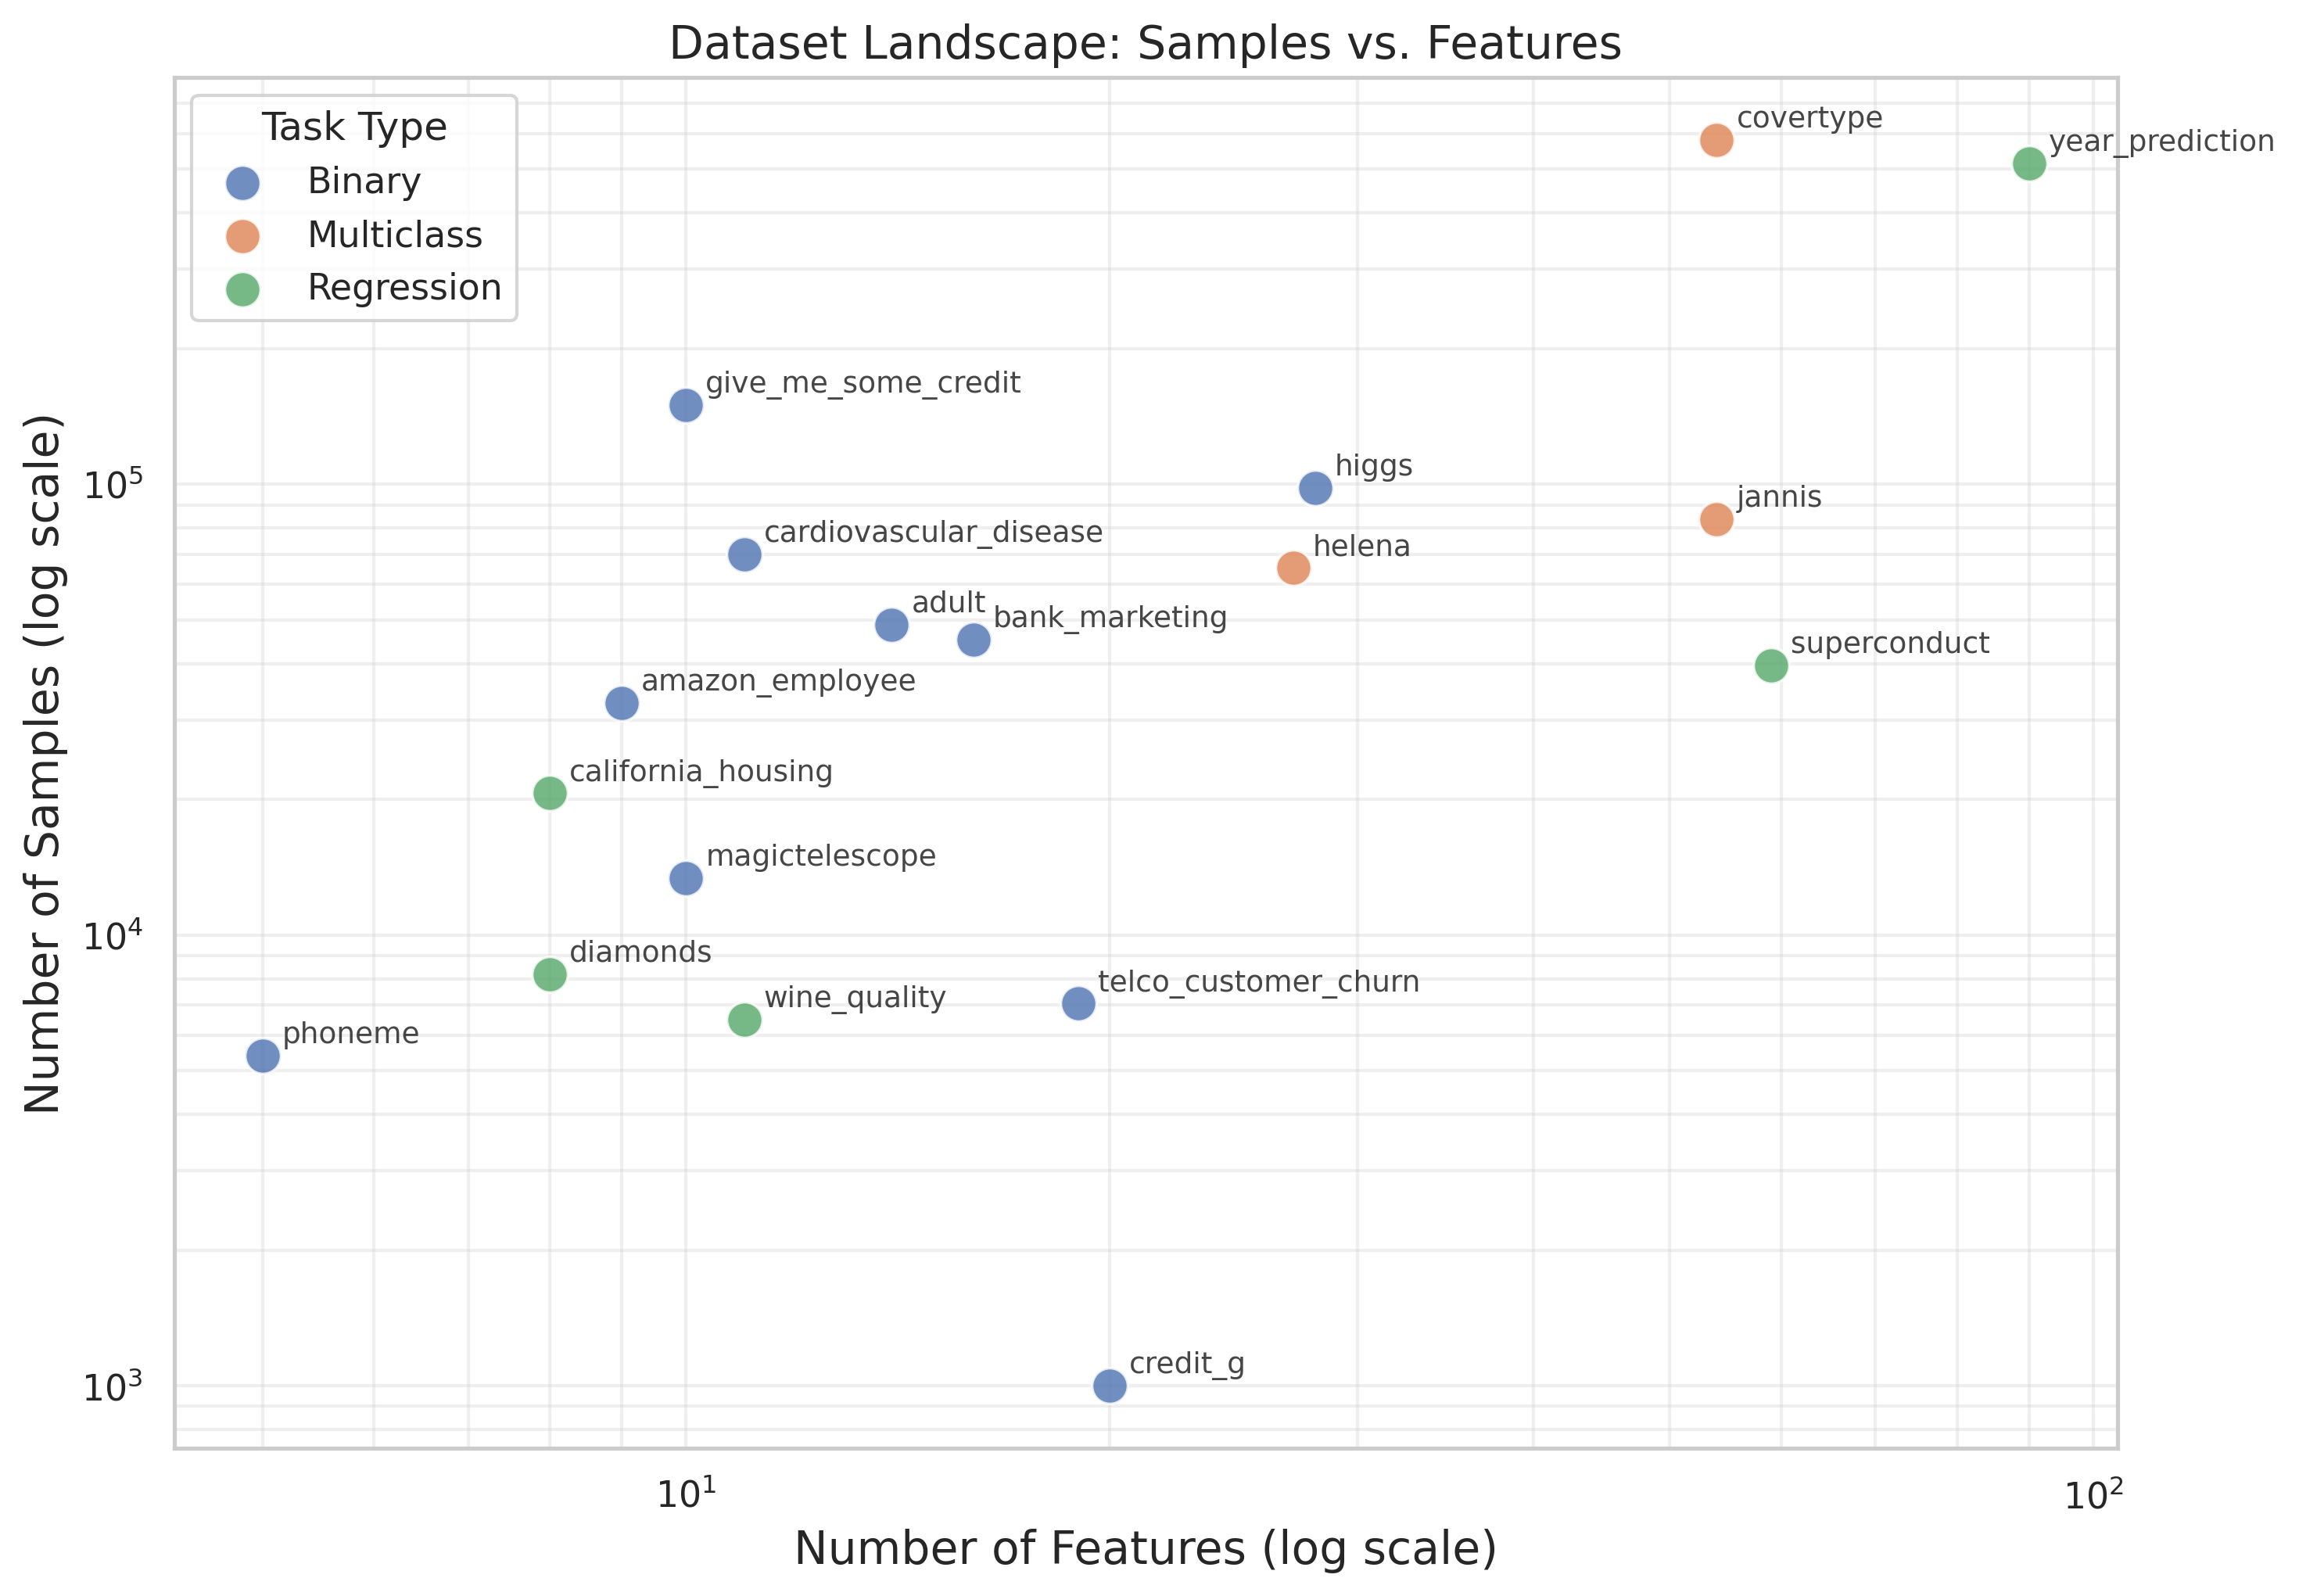

*Espaço amostras × features: o benchmark cobre 3 ordens de grandeza em tamanho e dimensionalidade.*

In [3]:
show('dataset_landscape.png', 'Espaço amostras × features: o benchmark cobre 3 ordens de grandeza em tamanho e dimensionalidade.', 720)

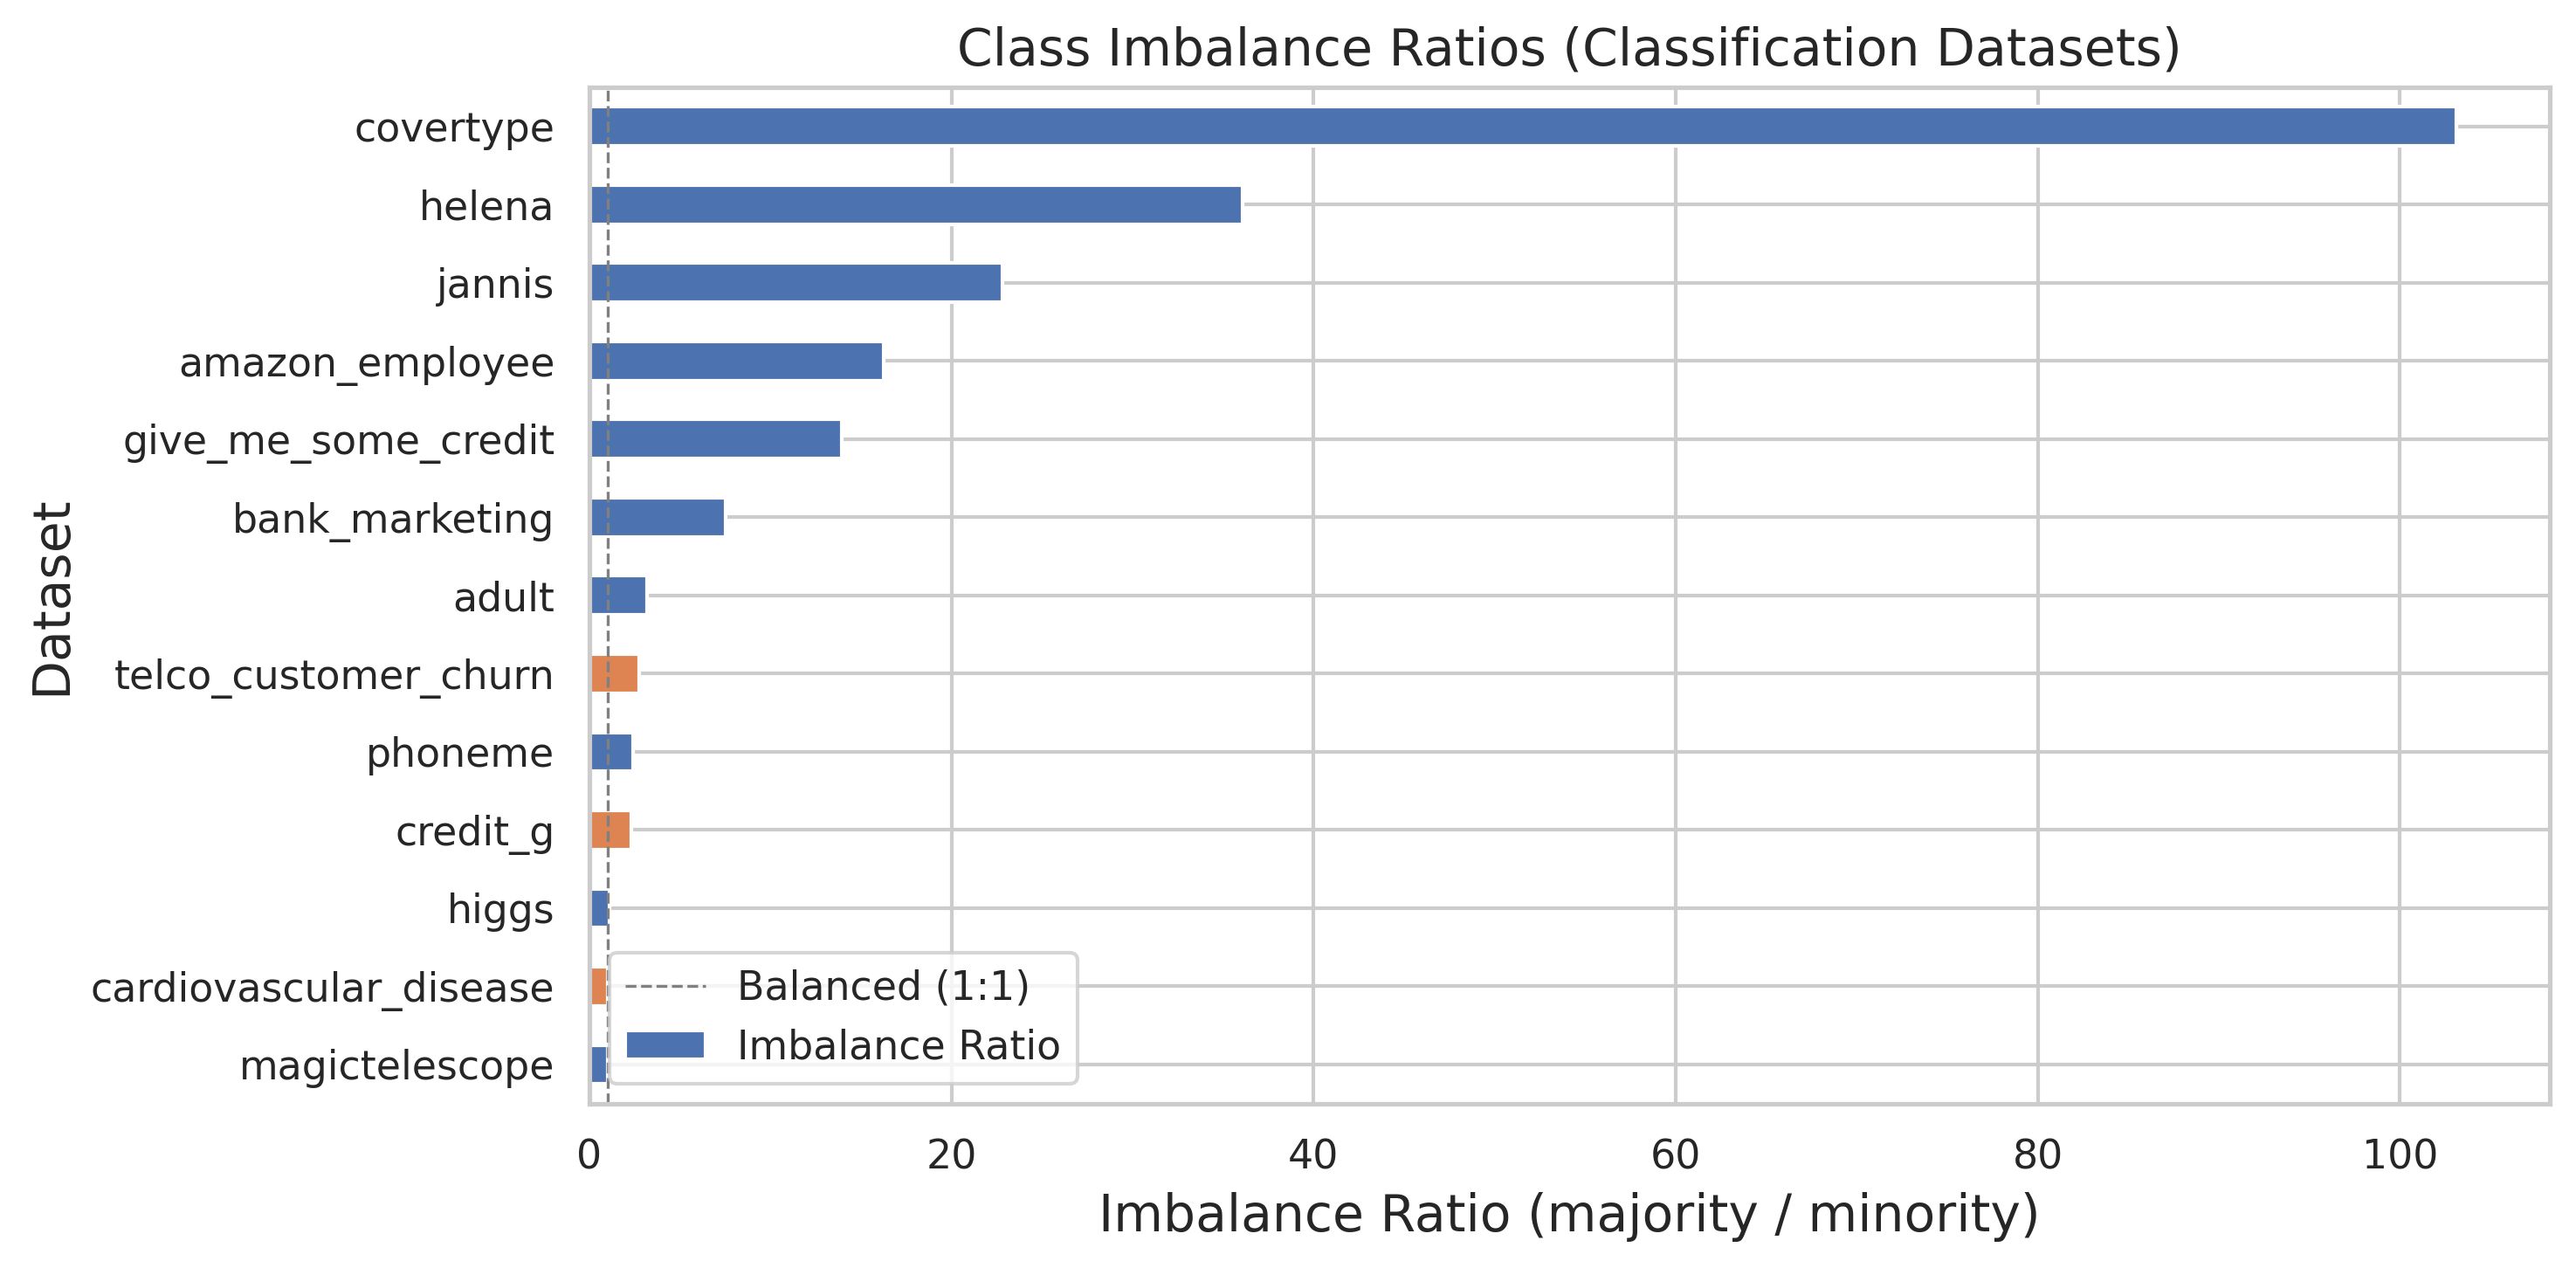

*Razões de desbalanceamento (classificação): de 1:1 a 16:1 — usado no eixo de robustez.*

In [4]:
show('class_imbalance.png', 'Razões de desbalanceamento (classificação): de 1:1 a 16:1 — usado no eixo de robustez.', 720)

---
## 4. Ato I — O Empate

**No desempenho bruto, o topo do campo é estatisticamente indistinguível.** O Friedman acusa que *existe*
diferença, mas o post-hoc (Nemenyi/CD) não separa o cluster de topo. Confirmamos com **dois** instrumentos
mais fortes que uma média: o teste **bayesiano (ROPE)** e a **decomposição de variância**.

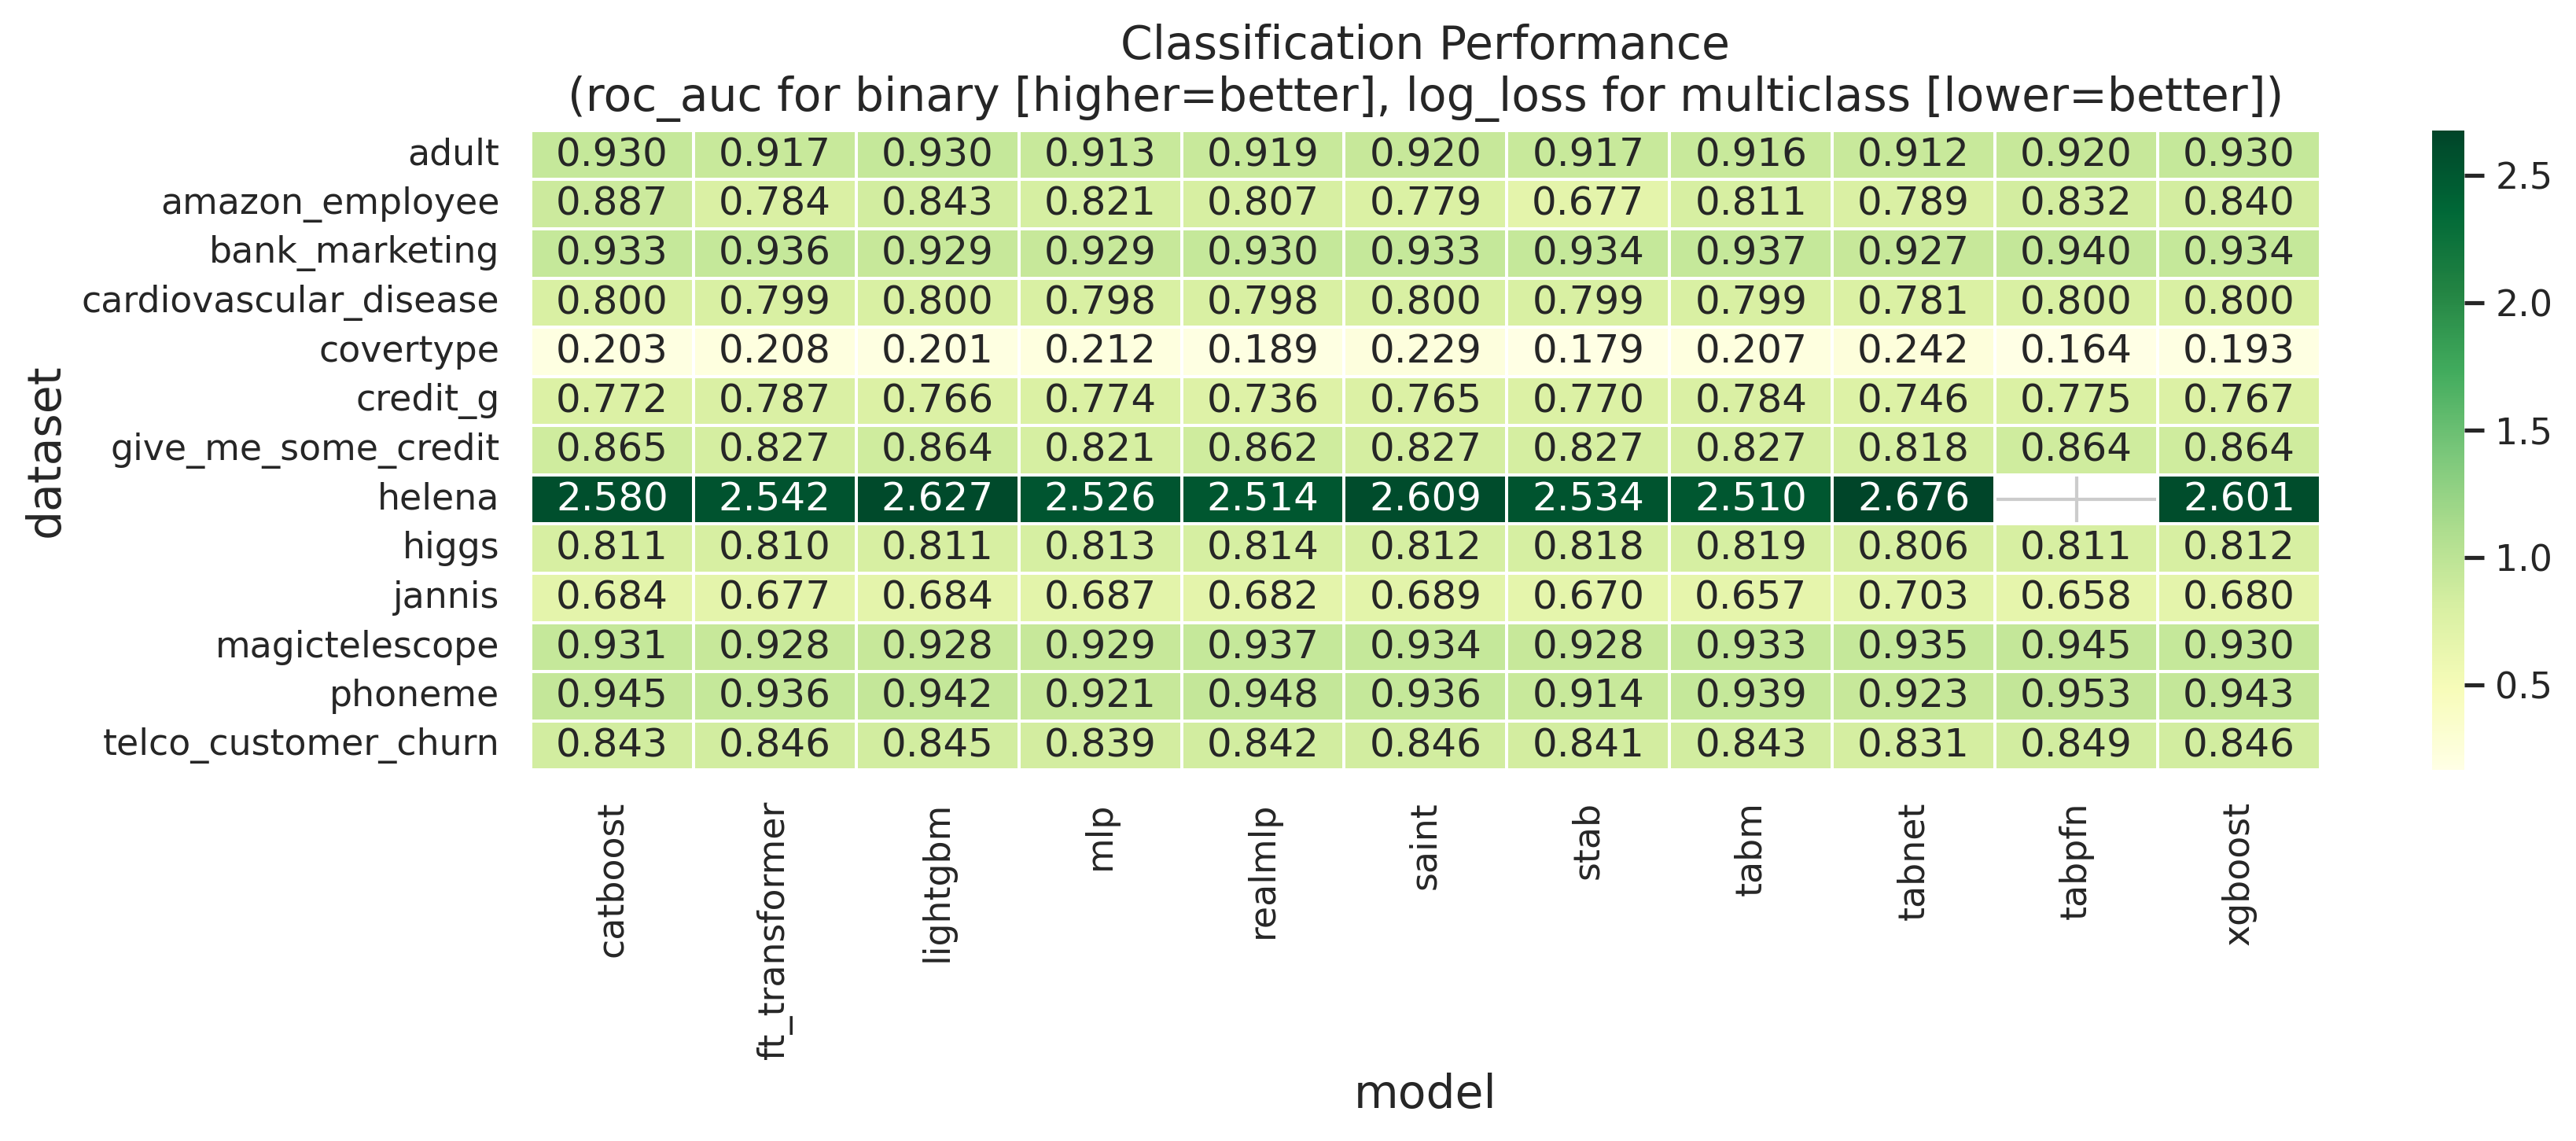

*Desempenho por modelo × dataset (ROC-AUC binária / log-loss multiclasse).*

In [5]:
show('heatmap_classification.png', 'Desempenho por modelo × dataset (ROC-AUC binária / log-loss multiclasse).', 880)

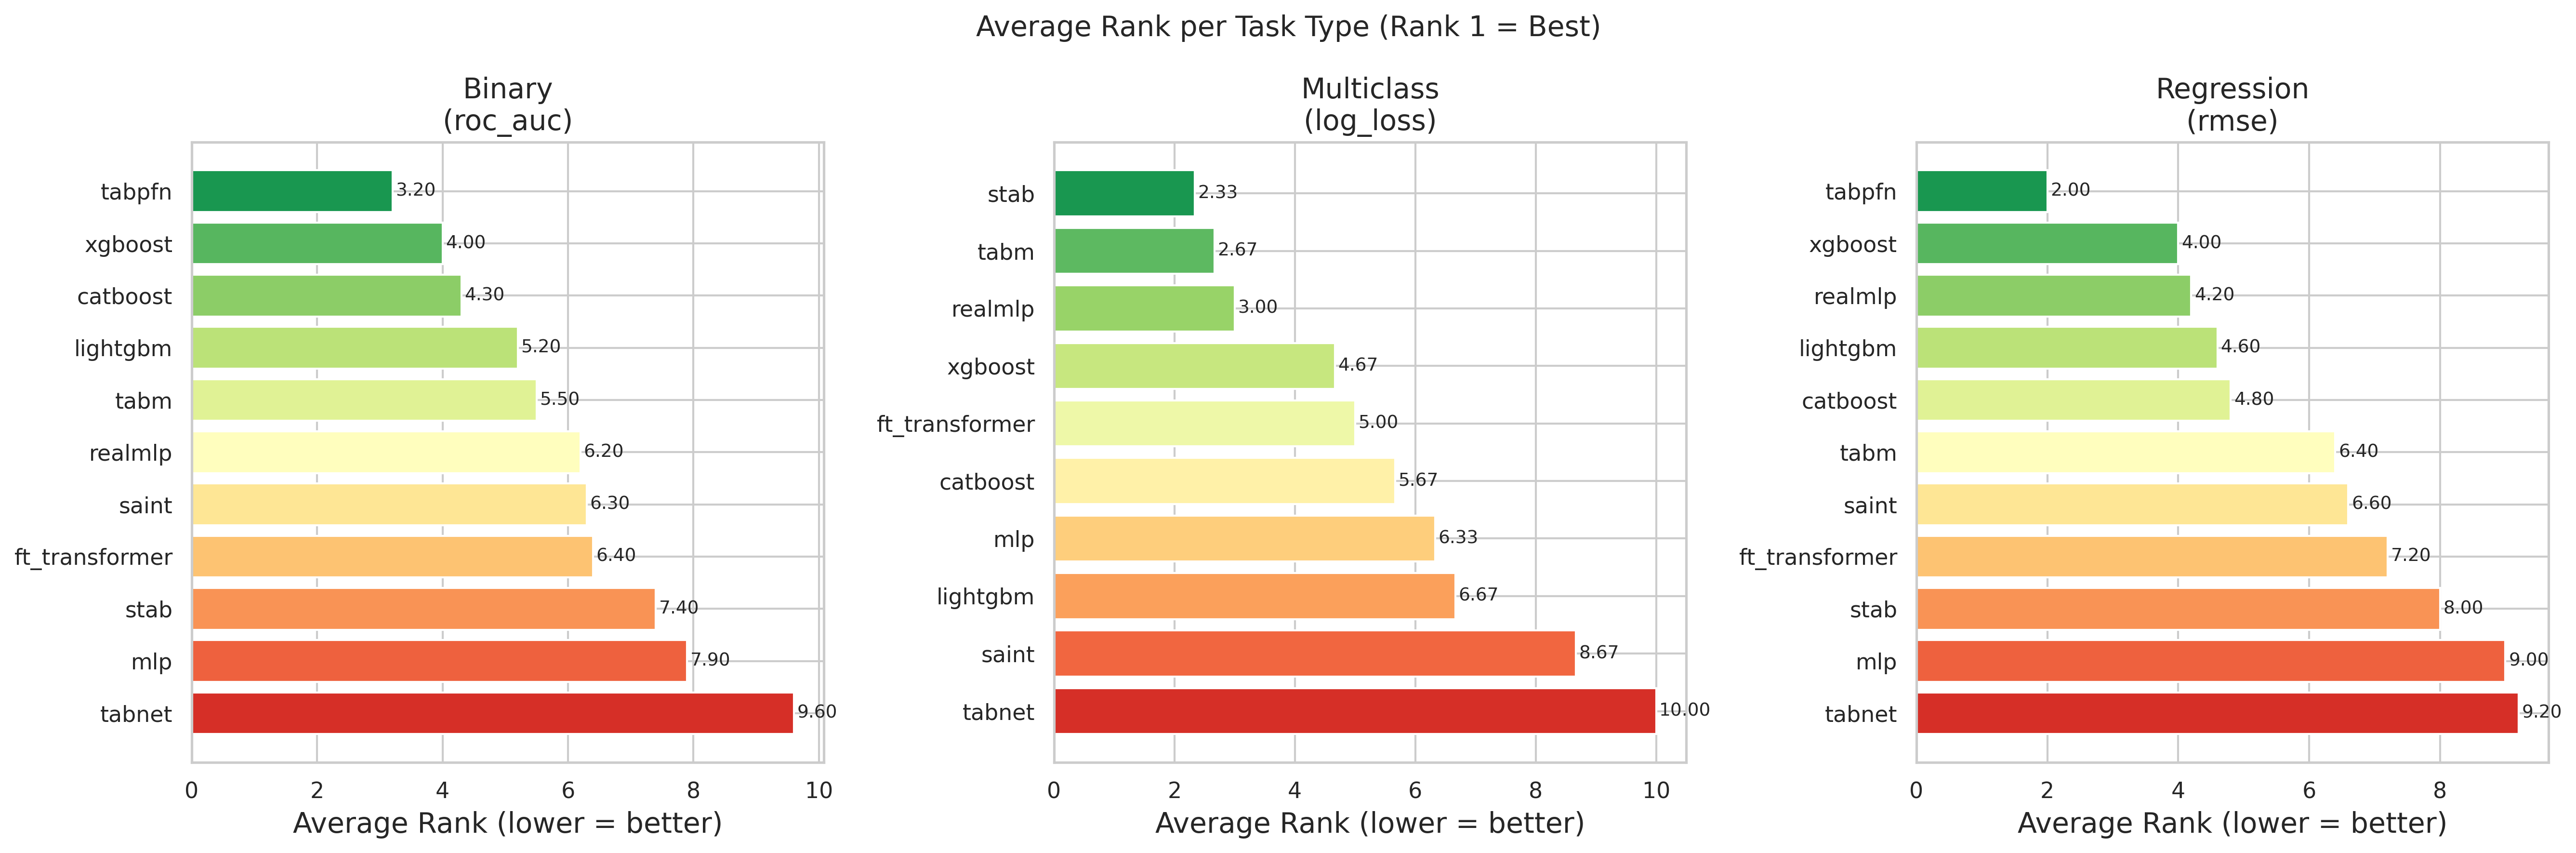

*Rank médio por tarefa (1 = melhor). TabPFN lidera binária/regressão; DL lidera multiclasse.*

In [6]:
show('average_ranks.png', 'Rank médio por tarefa (1 = melhor). TabPFN lidera binária/regressão; DL lidera multiclasse.', 880)

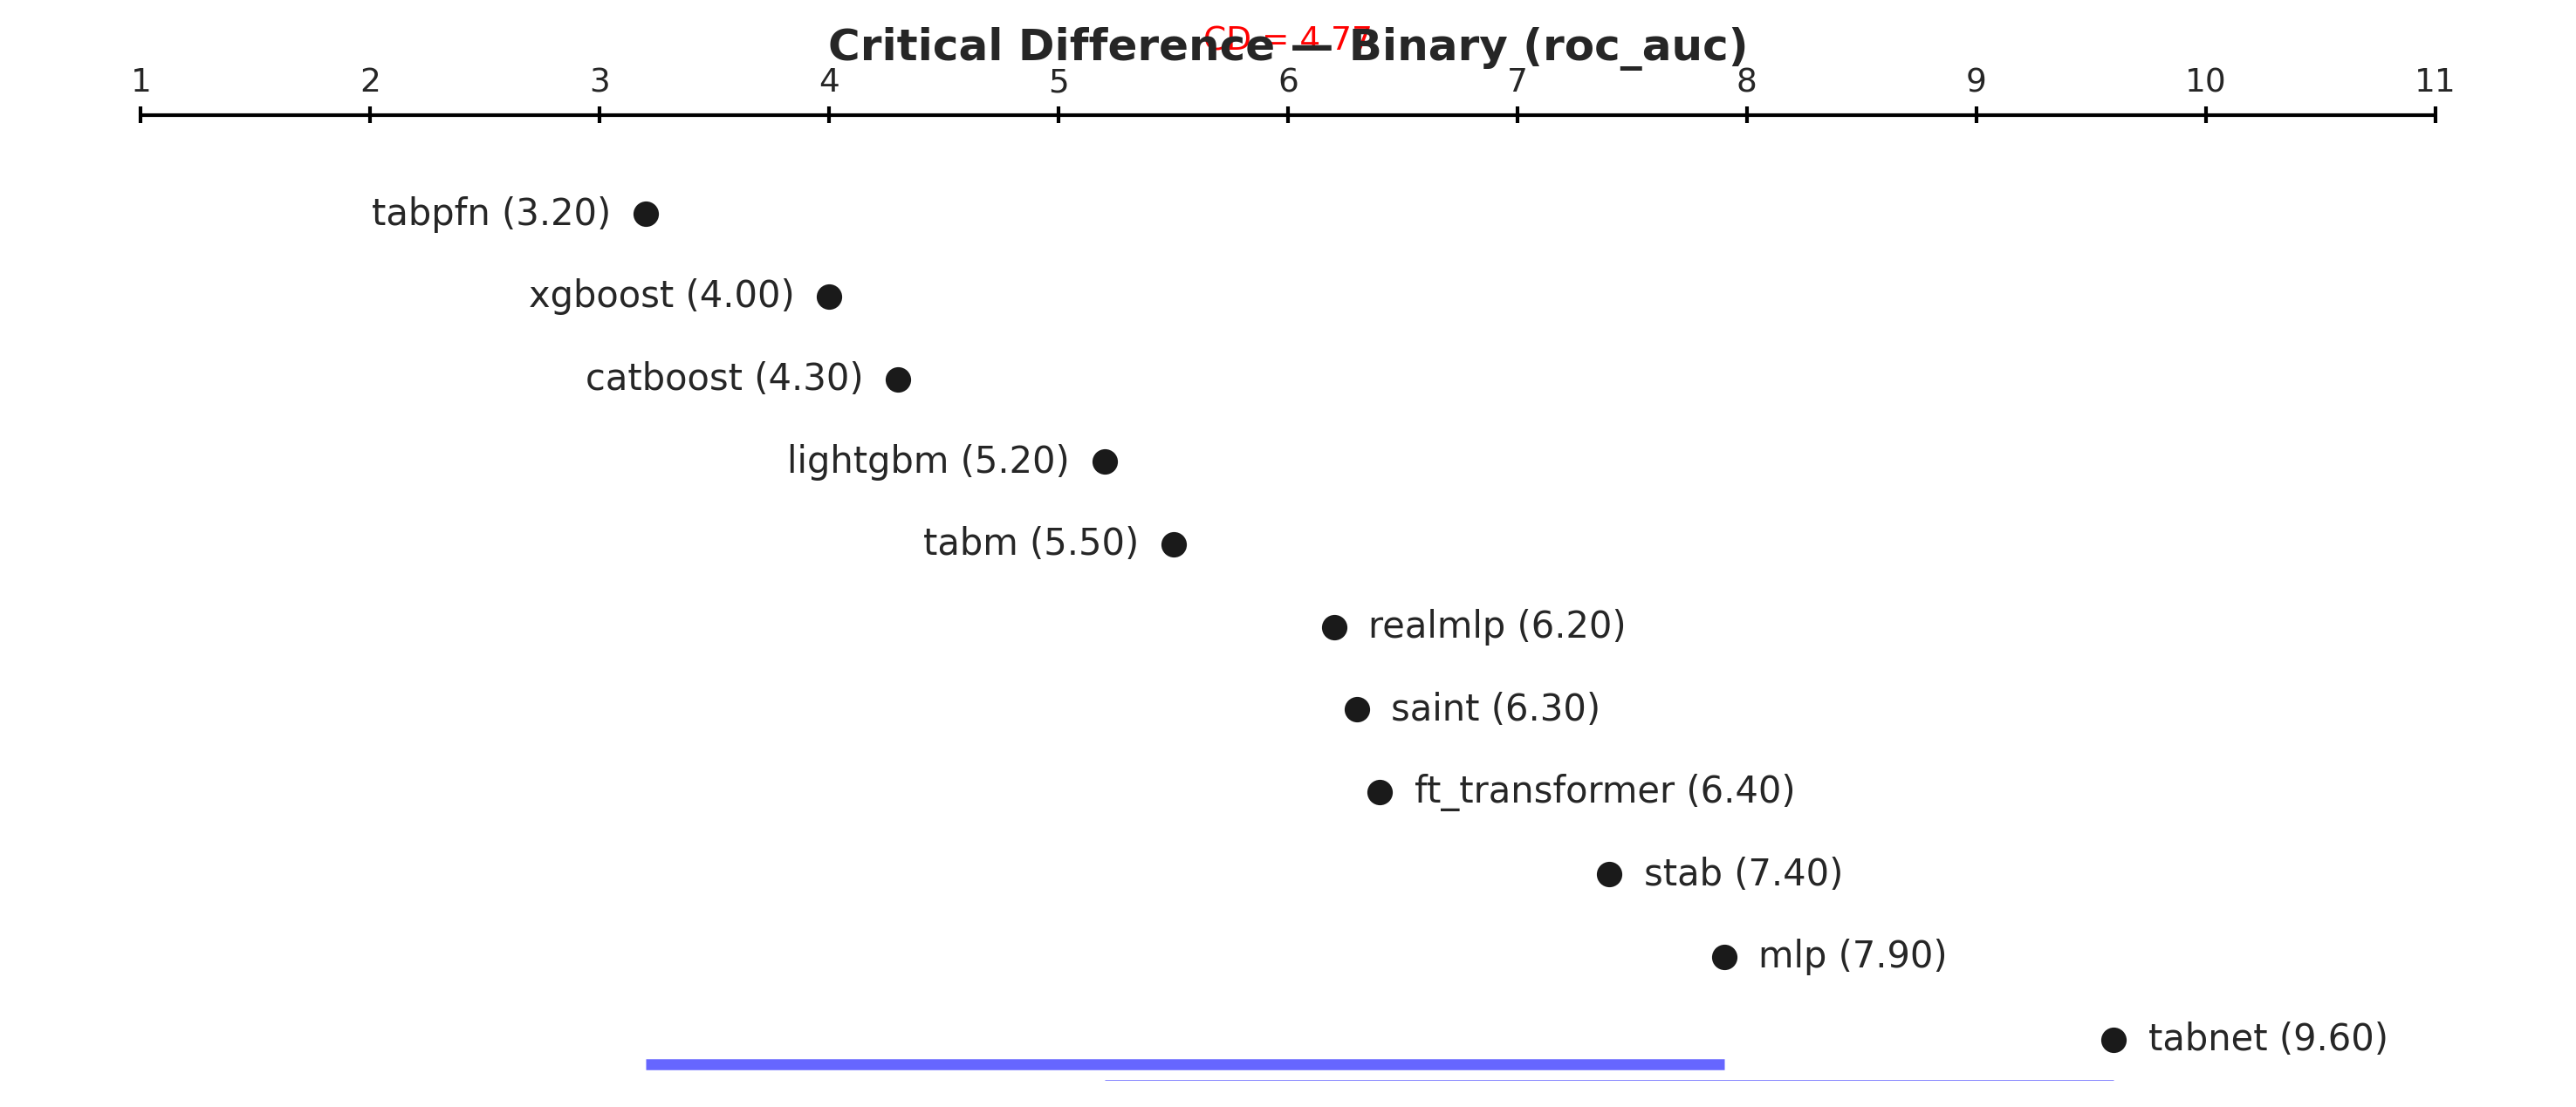

*Critical Difference (binária): modelos ligados pela barra NÃO são significativamente diferentes — o topo é um empate.*

In [7]:
show('cd_diagram_binary.png', 'Critical Difference (binária): modelos ligados pela barra NÃO são significativamente diferentes — o topo é um empate.', 720)

In [8]:
# Rigor do empate (1): teste bayesiano signed-rank vs o líder de rank (TabPFN), ROPE = 0.01 AUC
from src.models.factory import get_model_family
from src.evaluation.enrichments import bayesian_pairwise_table, family_variance_decomposition
test = pd.read_csv('../results/aggregated/test_results.csv')
FAM = {m: get_model_family(m) for m in test.model.unique()}
piv = test[test.task_type=='binary'].pivot(index='dataset', columns='model', values='roc_auc').dropna(axis=1)
bt = bayesian_pairwise_table(piv, higher_is_better=True, rope=0.01, ref='tabpfn').sort_values('P(better)', ascending=False)
print('Bayesian signed-rank vs TabPFN (binária, ROPE = +/-0.01 AUC):')
display(bt.round(2))
print(f"{(bt['P(equiv)']>0.5).sum()}/{len(bt)} modelos sao PRATICAMENTE EQUIVALENTES ao TabPFN (massa majoritaria dentro do ROPE).")

Bayesian signed-rank vs TabPFN (binária, ROPE = +/-0.01 AUC):


,model,vs,P(worse),P(equiv),P(better)
0,catboost,tabpfn,0.05,0.78,0.17
2,lightgbm,tabpfn,0.15,0.82,0.03
1,ft_transformer,tabpfn,0.44,0.54,0.02
3,mlp,tabpfn,0.49,0.51,0.00
4,realmlp,tabpfn,0.33,0.67,0.00
5,saint,tabpfn,0.44,0.56,0.00
6,stab,tabpfn,0.55,0.45,0.00
7,tabm,tabpfn,0.36,0.64,0.00
8,tabnet,tabpfn,0.82,0.18,0.00
9,xgboost,tabpfn,0.06,0.94,0.00


8/10 modelos sao PRATICAMENTE EQUIVALENTES ao TabPFN (massa majoritaria dentro do ROPE).


In [9]:
# Rigor do empate (2): a variancia de rank e' majoritariamente INTRA-familia
vd = family_variance_decomposition(piv.rank(axis=1, ascending=False), FAM)
print(f"eta^2 (parcela ENTRE-familias da variancia de rank) = {vd['eta_squared']:.2f}")
print(f"-> {(1-vd['eta_squared'])*100:.0f}% da variancia e' INTRA-familia: 'GBDT vs DL' e' uma abstracao fraca;")
print(f"   o modelo importa mais que a familia.  Ranks medios por familia: {vd['family_mean_rank']}")

eta^2 (parcela ENTRE-familias da variancia de rank) = 0.20
-> 80% da variancia e' INTRA-familia: 'GBDT vs DL' e' uma abstracao fraca;
   o modelo importa mais que a familia.  Ranks medios por familia: {'deep_learning': 7.043, 'foundation_model': 3.2, 'gbdt': 4.5}


**Leitura do Ato I.** A manchete não é *quem venceu* — é que *ninguém venceu por margem perceptível*.
A maioria dos competidores está dentro do ROPE do TabPFN (praticamente equivalentes), e 80% da variância
de rank é interna às famílias. *O único sinal robusto está no fundo: TabNet é consistentemente o pior.*

---
## 5. Ato II — Os Eixos Ocultos (custo)

Os modelos que empatam em acurácia são **radicalmente diferentes em custo**: tempo de treino varia ~300×,
latência de inferência **~26.000×**. E o ranking de custo é quase o *inverso* da intuição.

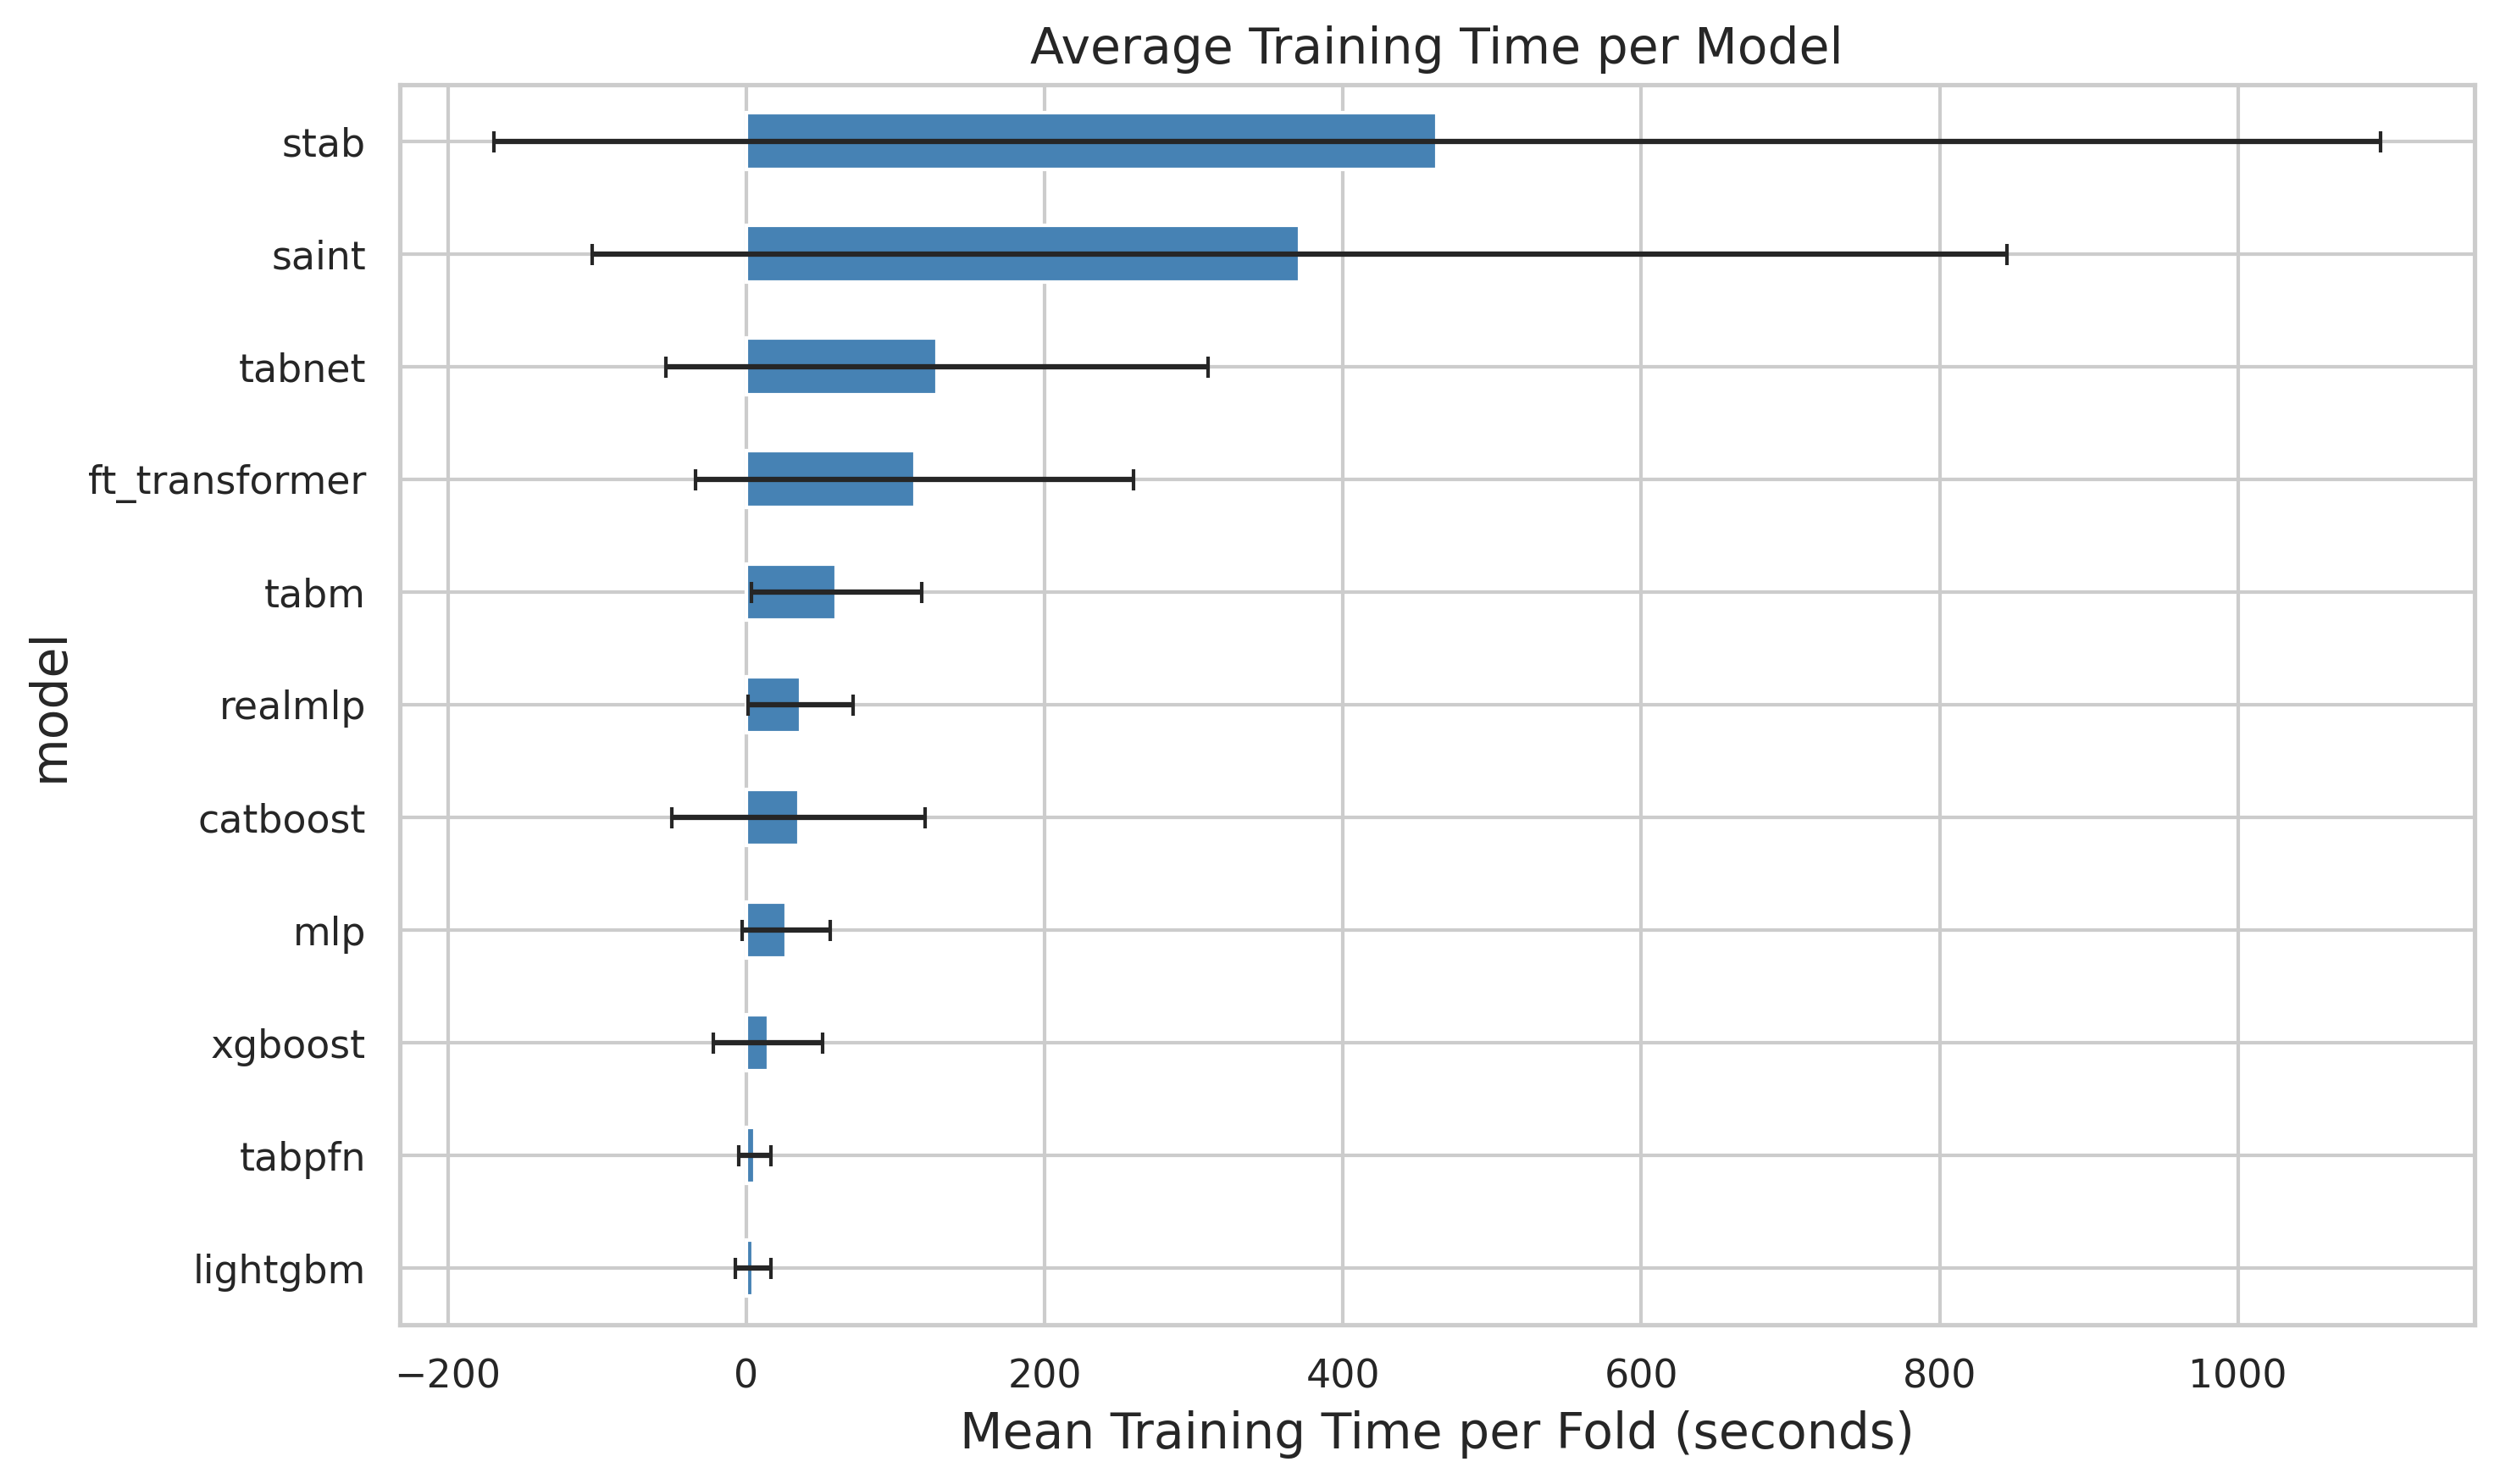

*Tempo de treino do modelo final (mediana). GBDTs e TabPFN: ~1-4s; DL pesado: minutos por fit.*

In [10]:
show('training_time.png', 'Tempo de treino do modelo final (mediana). GBDTs e TabPFN: ~1-4s; DL pesado: minutos por fit.', 720)

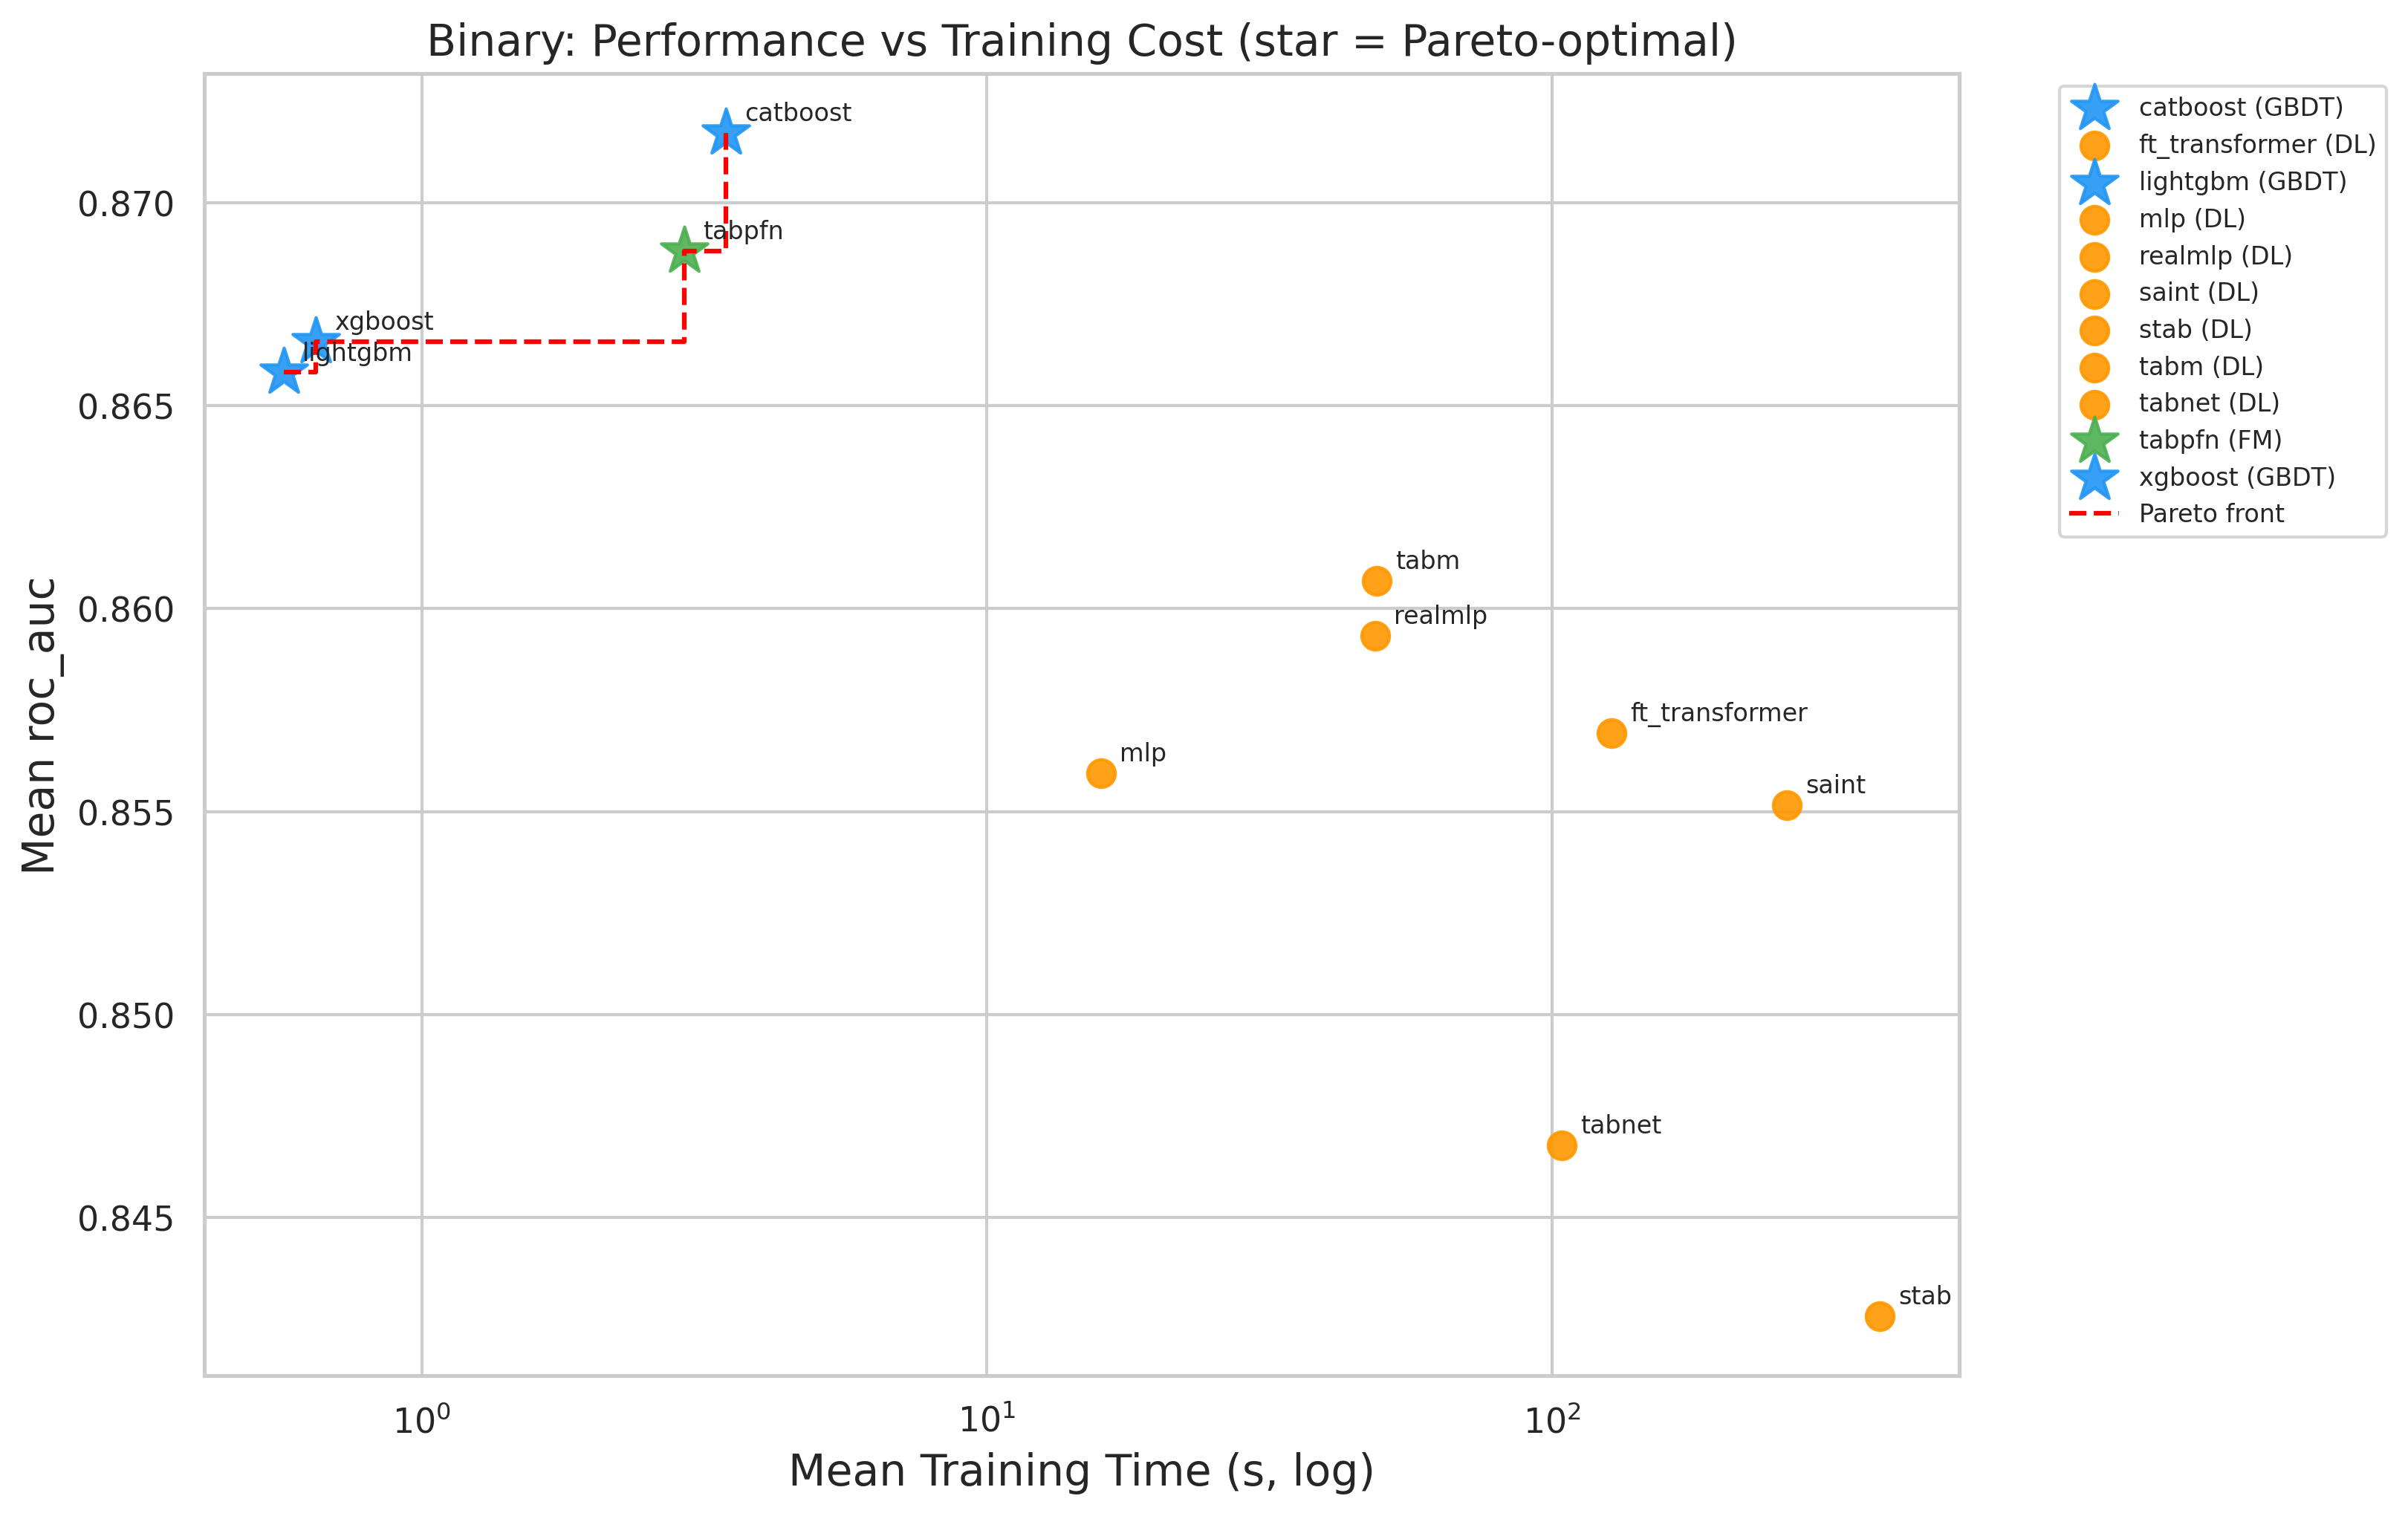

*Fronteira de Pareto custo×desempenho (binária): a fronteira e' {TabPFN, XGBoost, LightGBM} — todo DL e' dominado.*

In [11]:
show('pareto_binary.png', 'Fronteira de Pareto custo×desempenho (binária): a fronteira e\' {TabPFN, XGBoost, LightGBM} — todo DL e\' dominado.', 760)

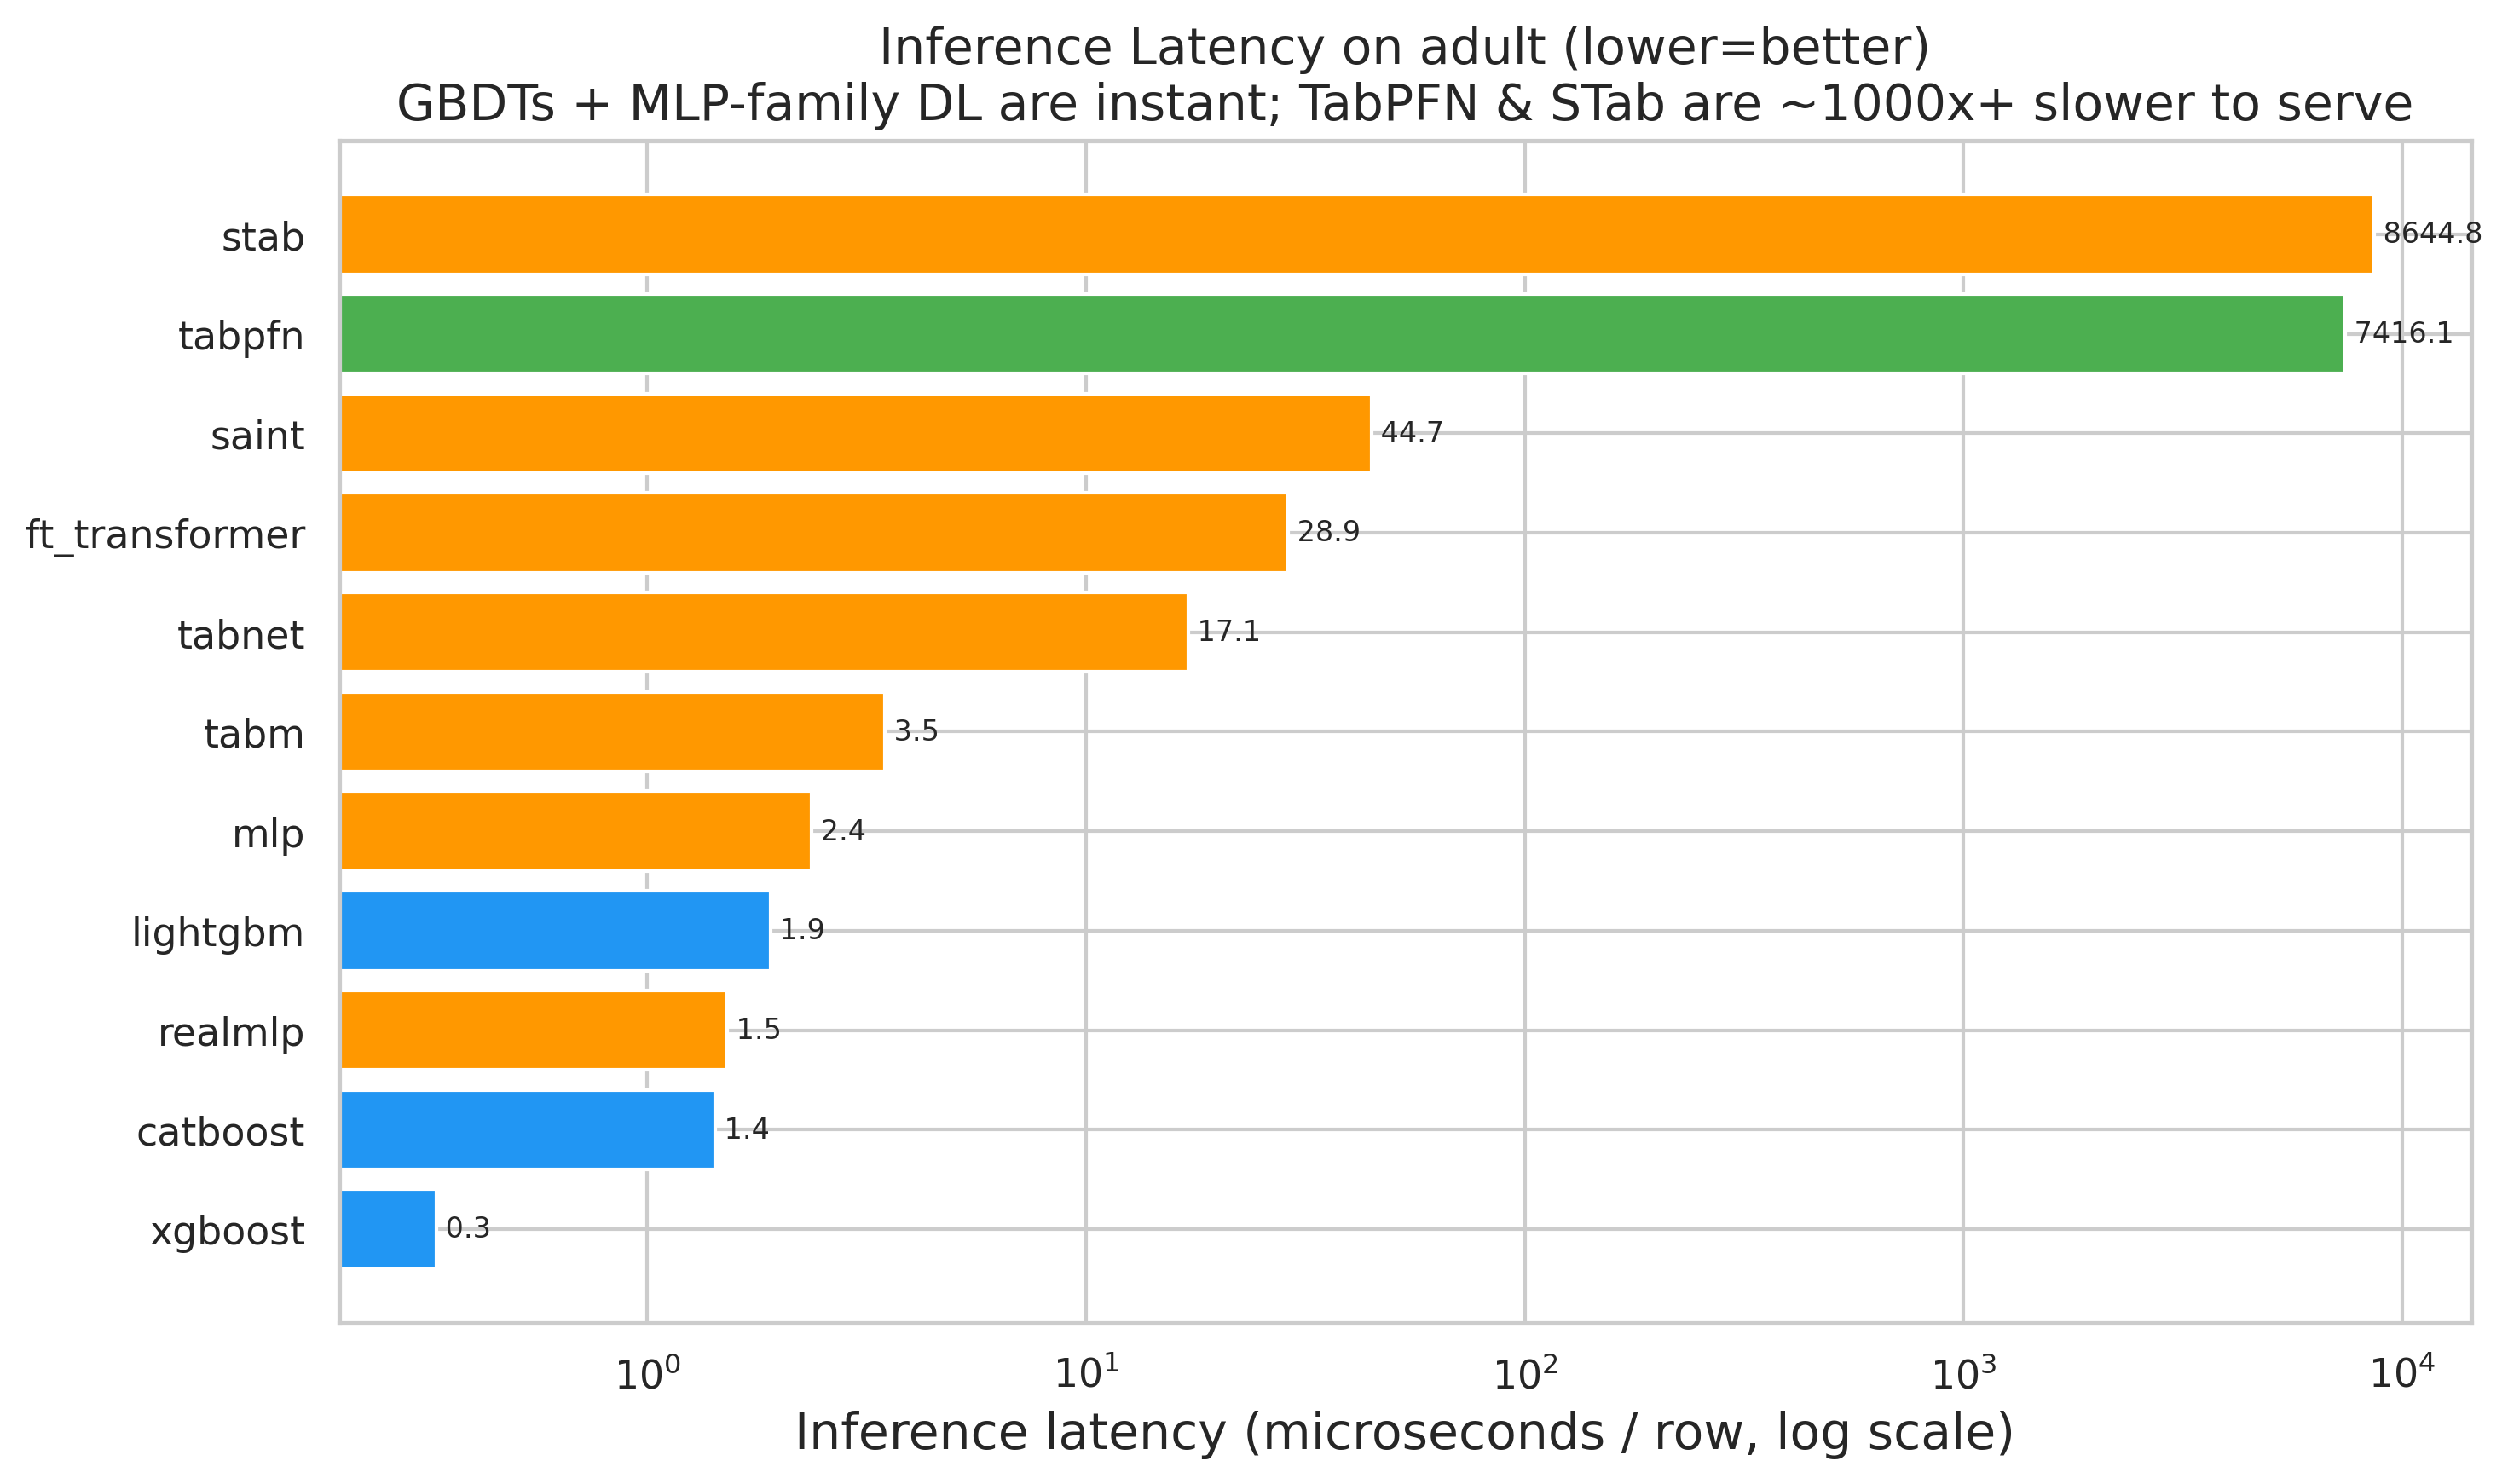

*Latencia de inferencia (adult). A INVERSAO do TabPFN: o mais barato de treinar e' o 2o mais caro de servir (~22.000x mais lento que XGBoost).*

In [12]:
show('inference_time.png', 'Latencia de inferencia (adult). A INVERSAO do TabPFN: o mais barato de treinar e\' o 2o mais caro de servir (~22.000x mais lento que XGBoost).', 760)

**Leitura do Ato II.** Custo é o primeiro eixo onde as famílias separam *limpo*. **A inversão do TabPFN**
é o achado-âncora: barato de treinar (~1s, zero tuning), caríssimo de servir. E latência **não** é um
corte "árvore vs rede" — é arquitetural: o *tier* rápido inclui os 3 GBDTs **e** os DL tipo-MLP
(RealMLP/MLP/TabM); só atenção, in-context (TabPFN) e *sampling* (STab) são lentos.

---
## 6. Ato III — As Reversões (o desempenho é condicional)

A melhor família **depende da estrutura do problema**: tarefa, tamanho, desbalanceamento e tipo de feature.

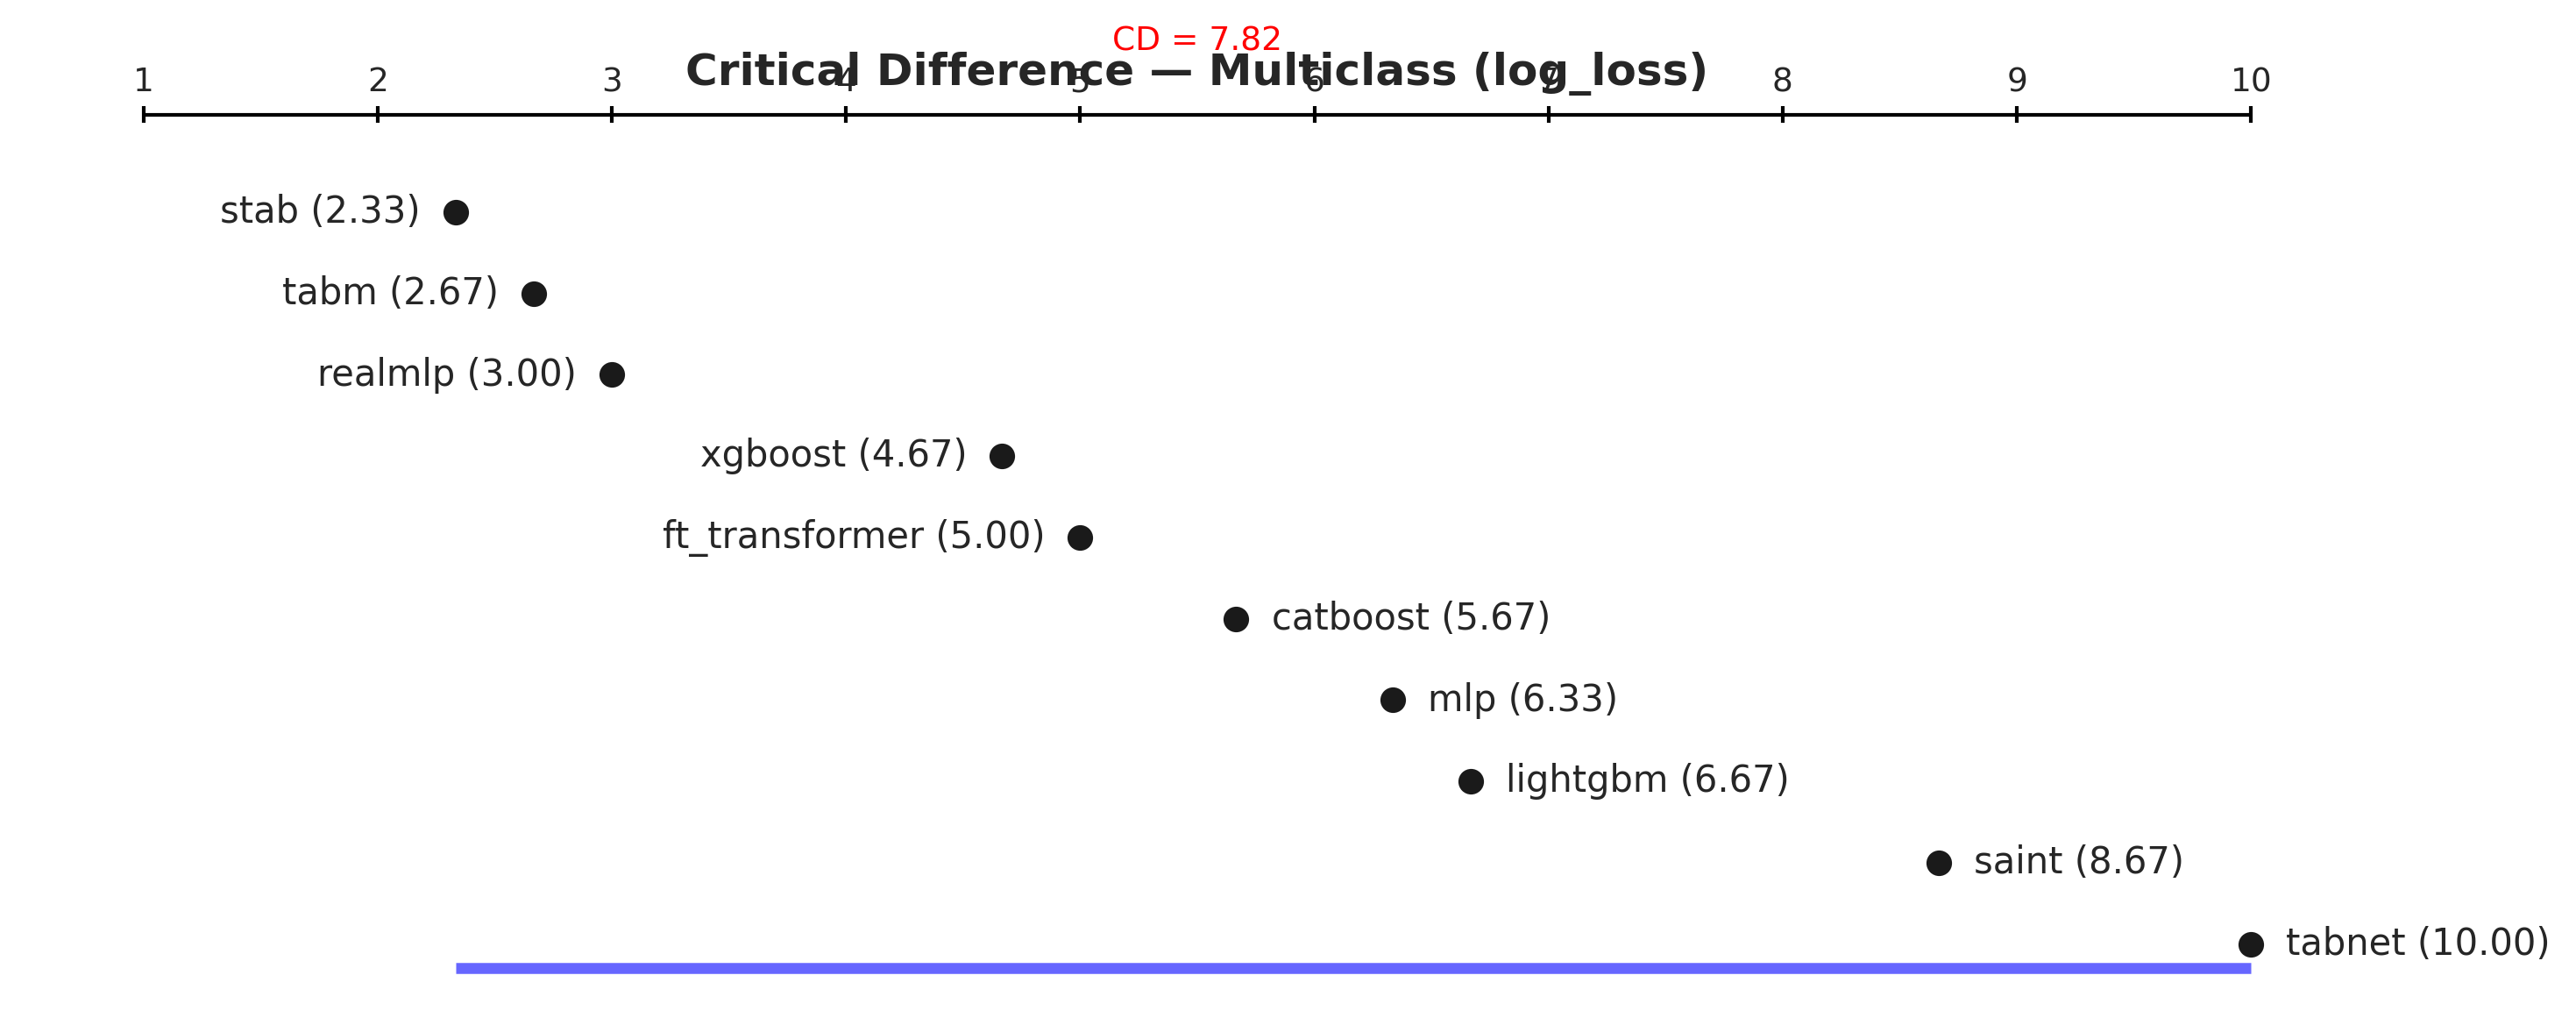

*CD multiclasse: STab/TabM/RealMLP (DL) topam — a reversao mais marcante do benchmark (descritivo, N=3).*

In [13]:
show('cd_diagram_multiclass.png', 'CD multiclasse: STab/TabM/RealMLP (DL) topam — a reversao mais marcante do benchmark (descritivo, N=3).', 720)

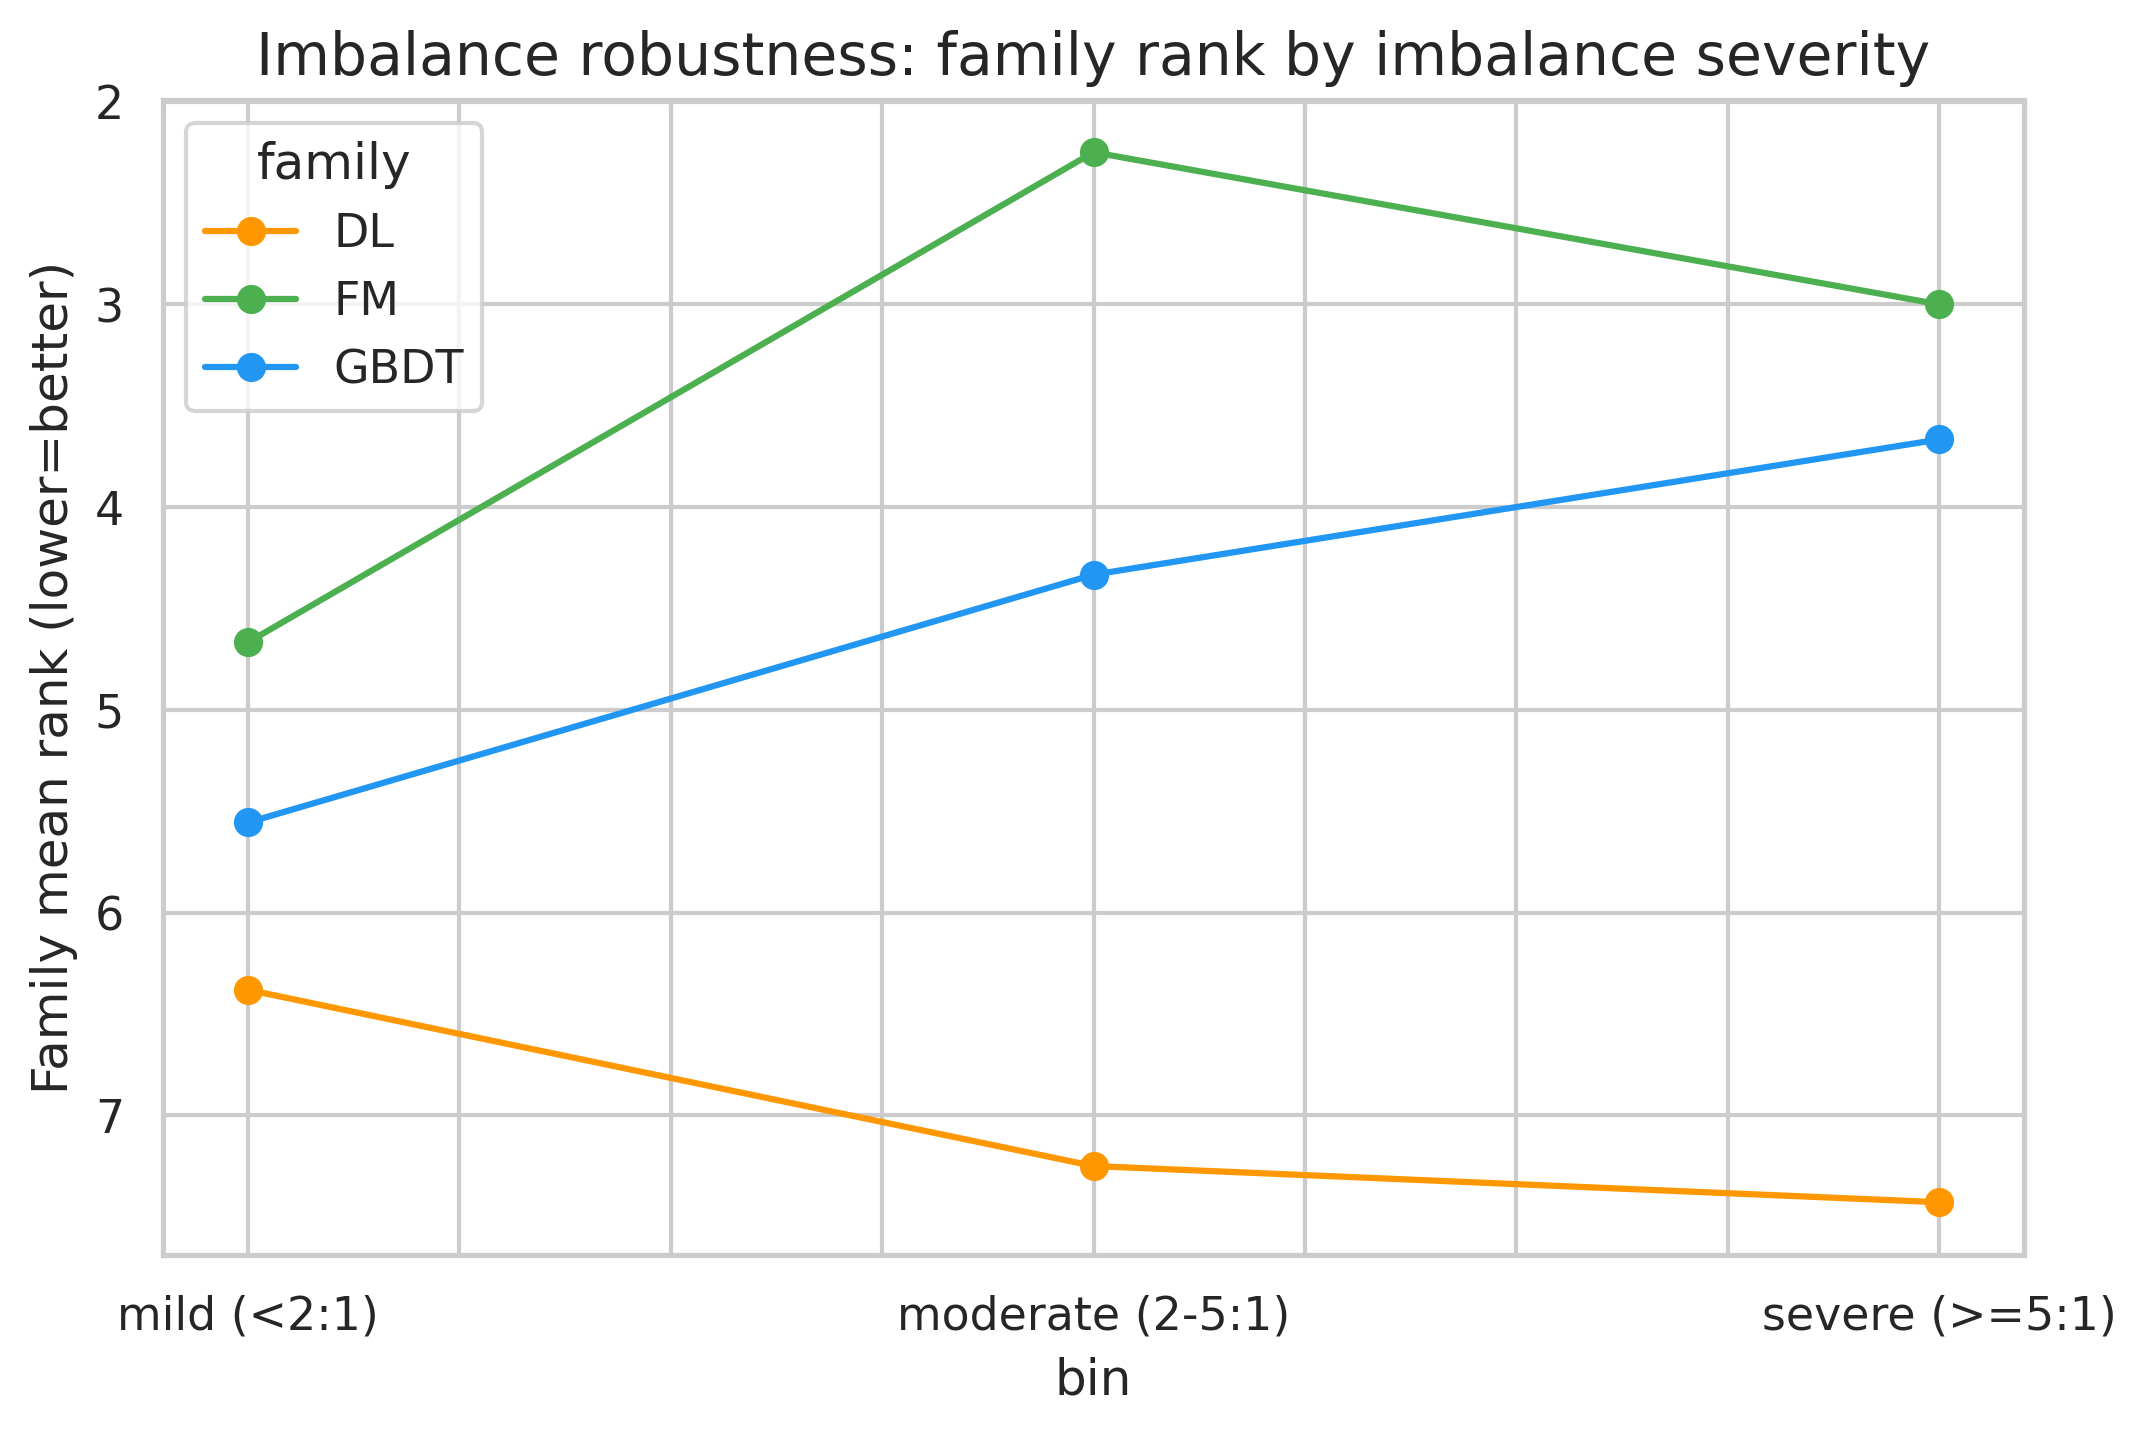

*Robustez ao desbalanceamento: GBDT melhora conforme a minoria fica rara; DL piora; TabPFN no meio.*

In [14]:
show('imbalance_robustness.png', 'Robustez ao desbalanceamento: GBDT melhora conforme a minoria fica rara; DL piora; TabPFN no meio.', 680)

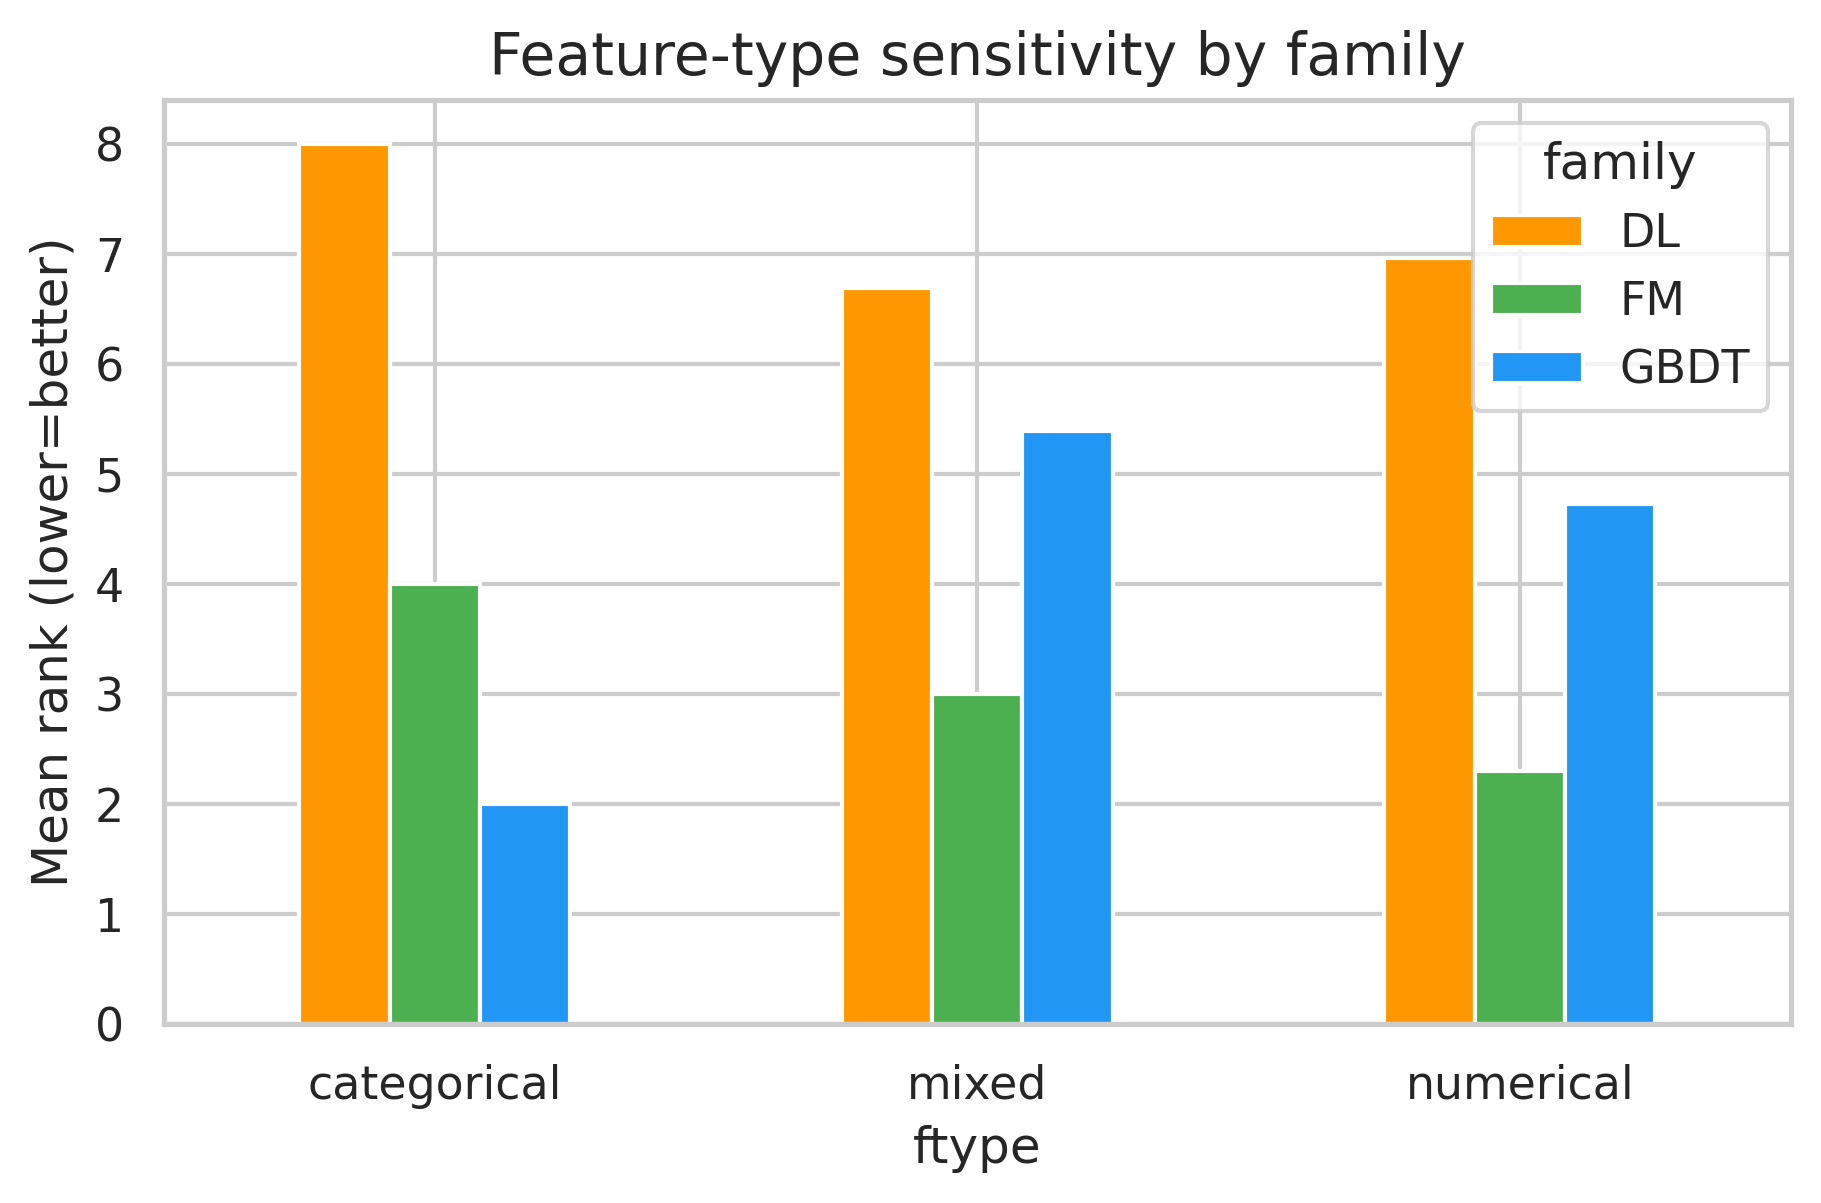

*Sensibilidade ao tipo de feature: o gargalo de one-hot do DL aparece no extremo categorico.*

In [15]:
show('feature_type_sensitivity.png', 'Sensibilidade ao tipo de feature: o gargalo de one-hot do DL aparece no extremo categorico.', 640)

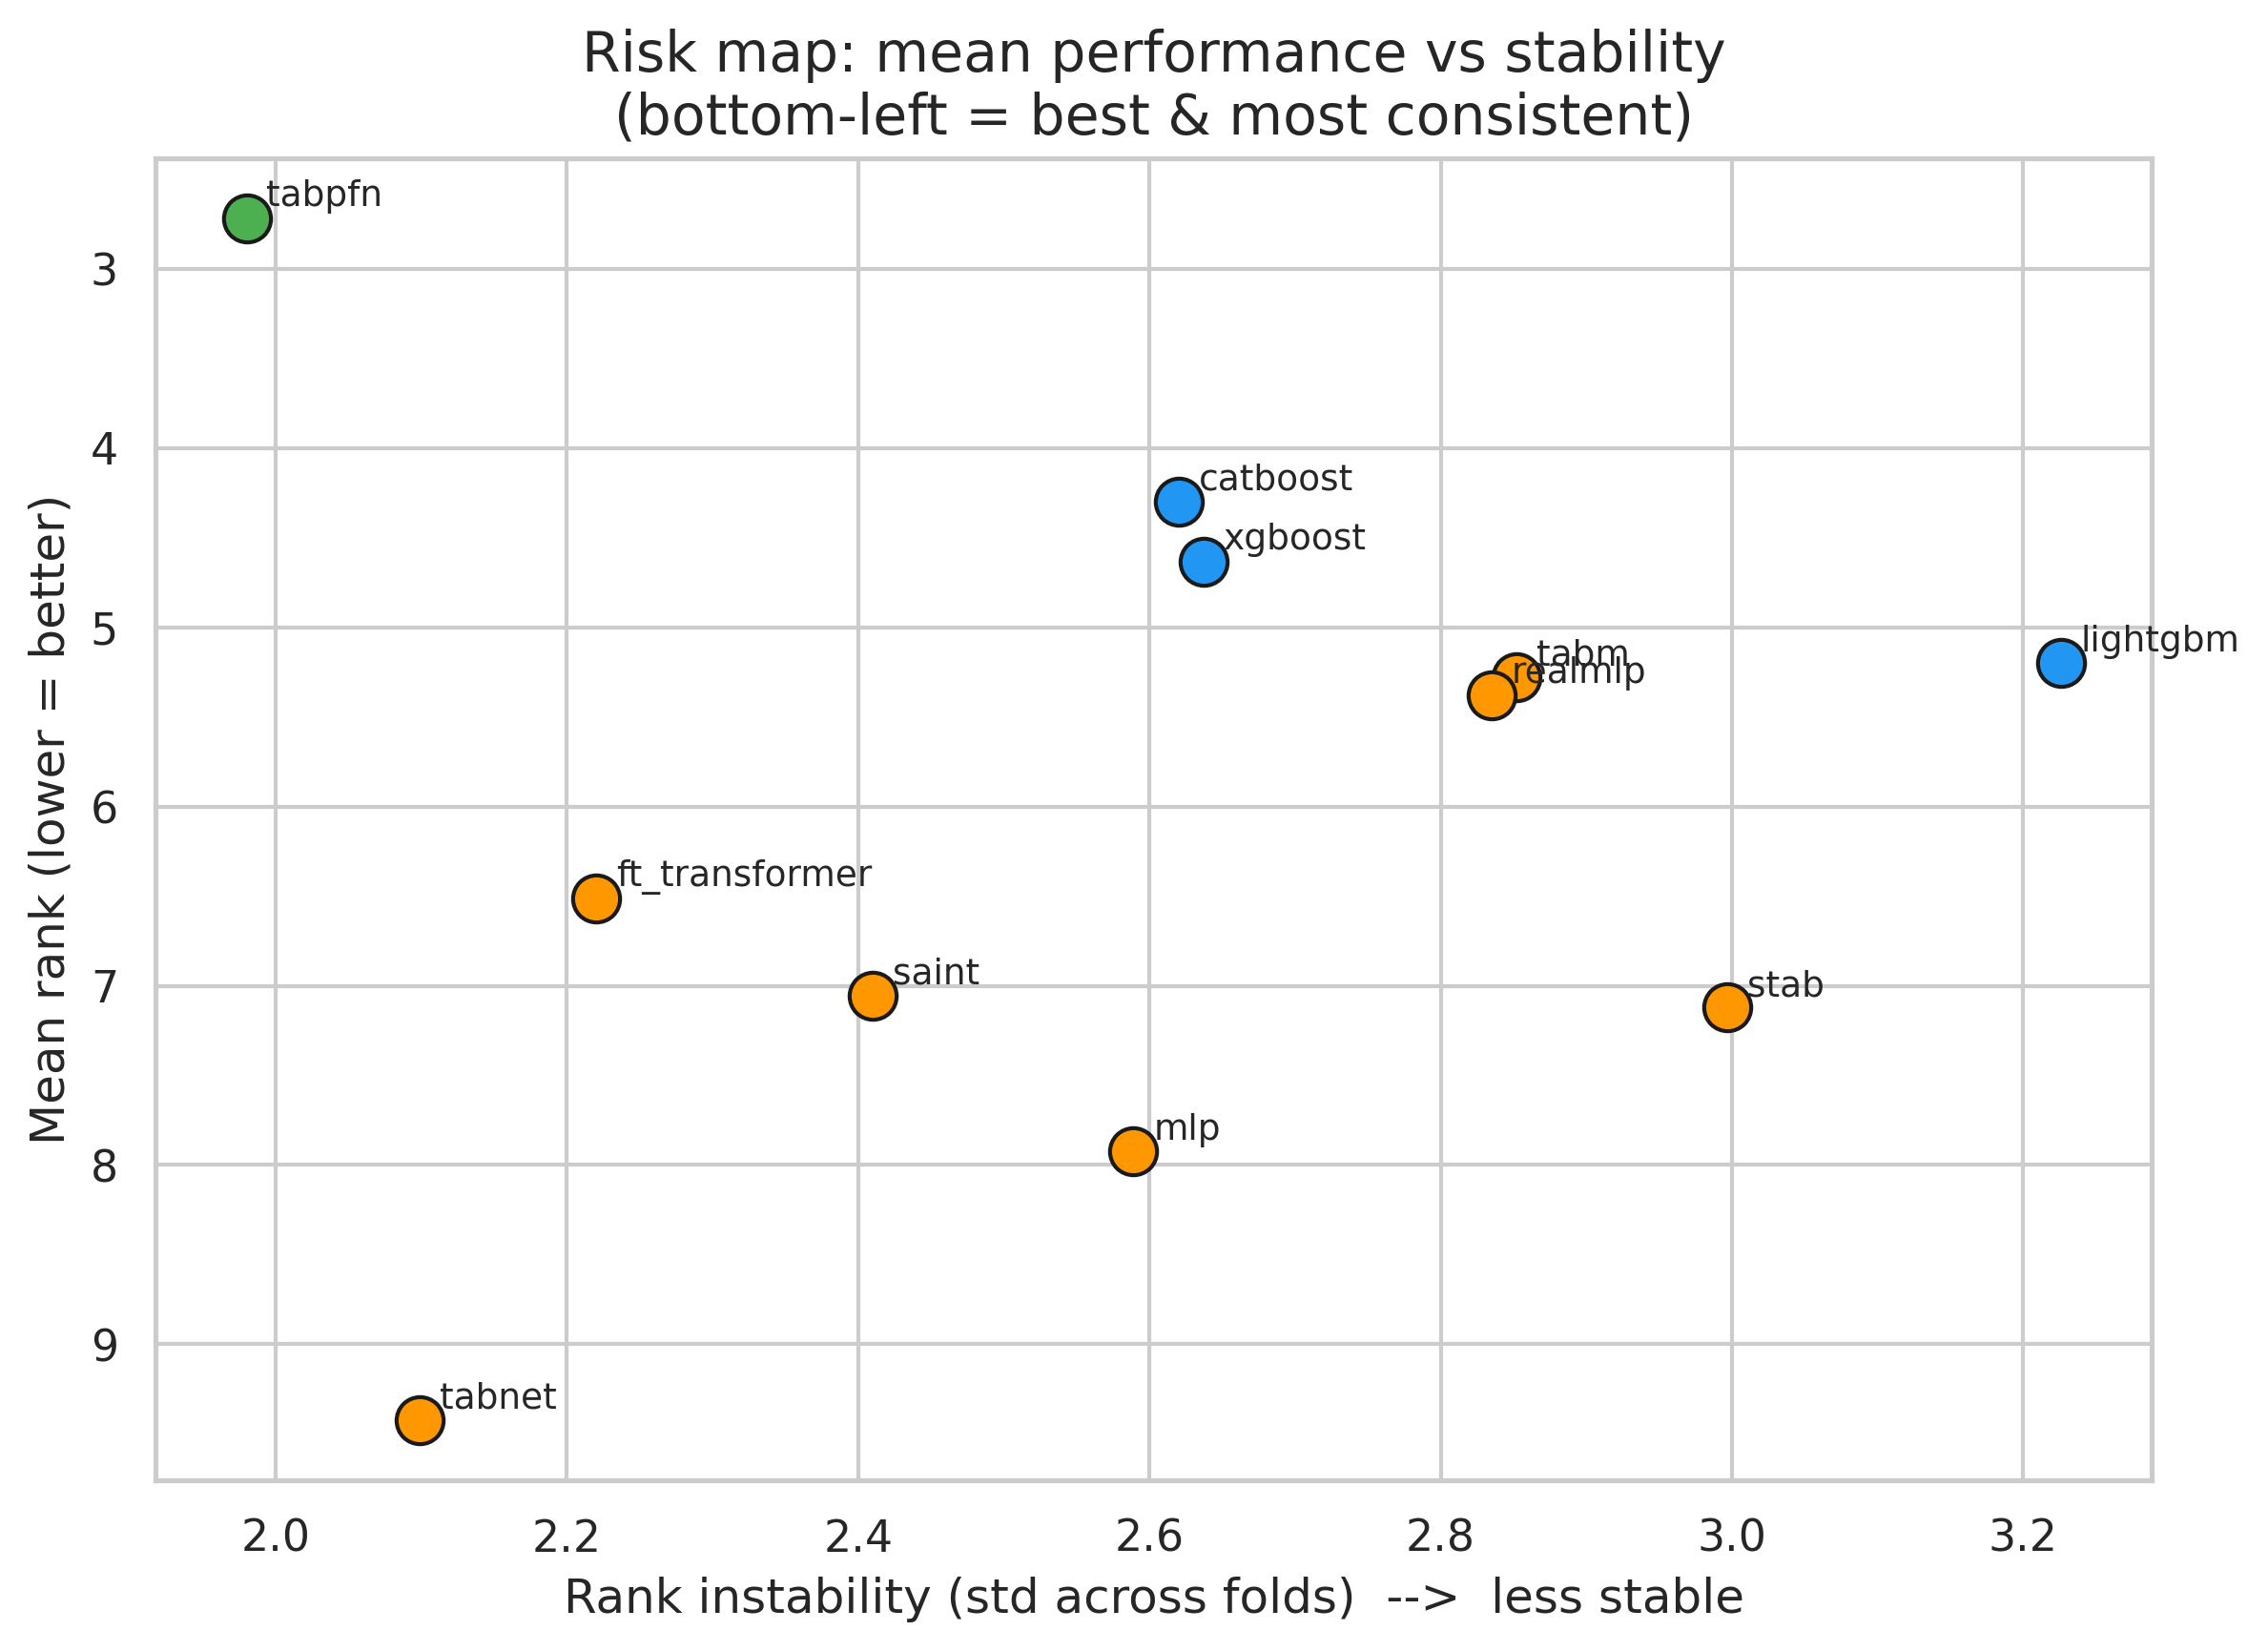

*Mapa de risco: TabPFN tem o melhor rank medio E o maior piso (raramente catastrofico); os demais caem a rank 10-11 em algum fold.*

In [16]:
show('robustness_riskmap.png', 'Mapa de risco: TabPFN tem o melhor rank medio E o maior piso (raramente catastrofico); os demais caem a rank 10-11 em algum fold.', 720)

**Leitura do Ato III.** GBDTs/TabPFN lideram binária e regressão, mas **DL reverte à frente em multiclasse**;
GBDTs ficam relativamente mais fortes sob desbalanceamento; atenção quebra em dados categóricos (one-hot).
E, em risco: **TabPFN raramente é catastrófico** — todo o resto tem um fold ruim.

---
## 7. Ponte Ato III → IV — dá para *prever* o vencedor?

As reversões não são aleatórias: elas seguem **meta-features** do dataset (tamanho, dimensionalidade,
fração categórica). Uma árvore pequena e interpretável recupera quem vence — e seus *splits* viram as
ramificações do flowchart. *(Descritivo: N=18, sem held-out — ilustra a estrutura, não é um preditor.)*

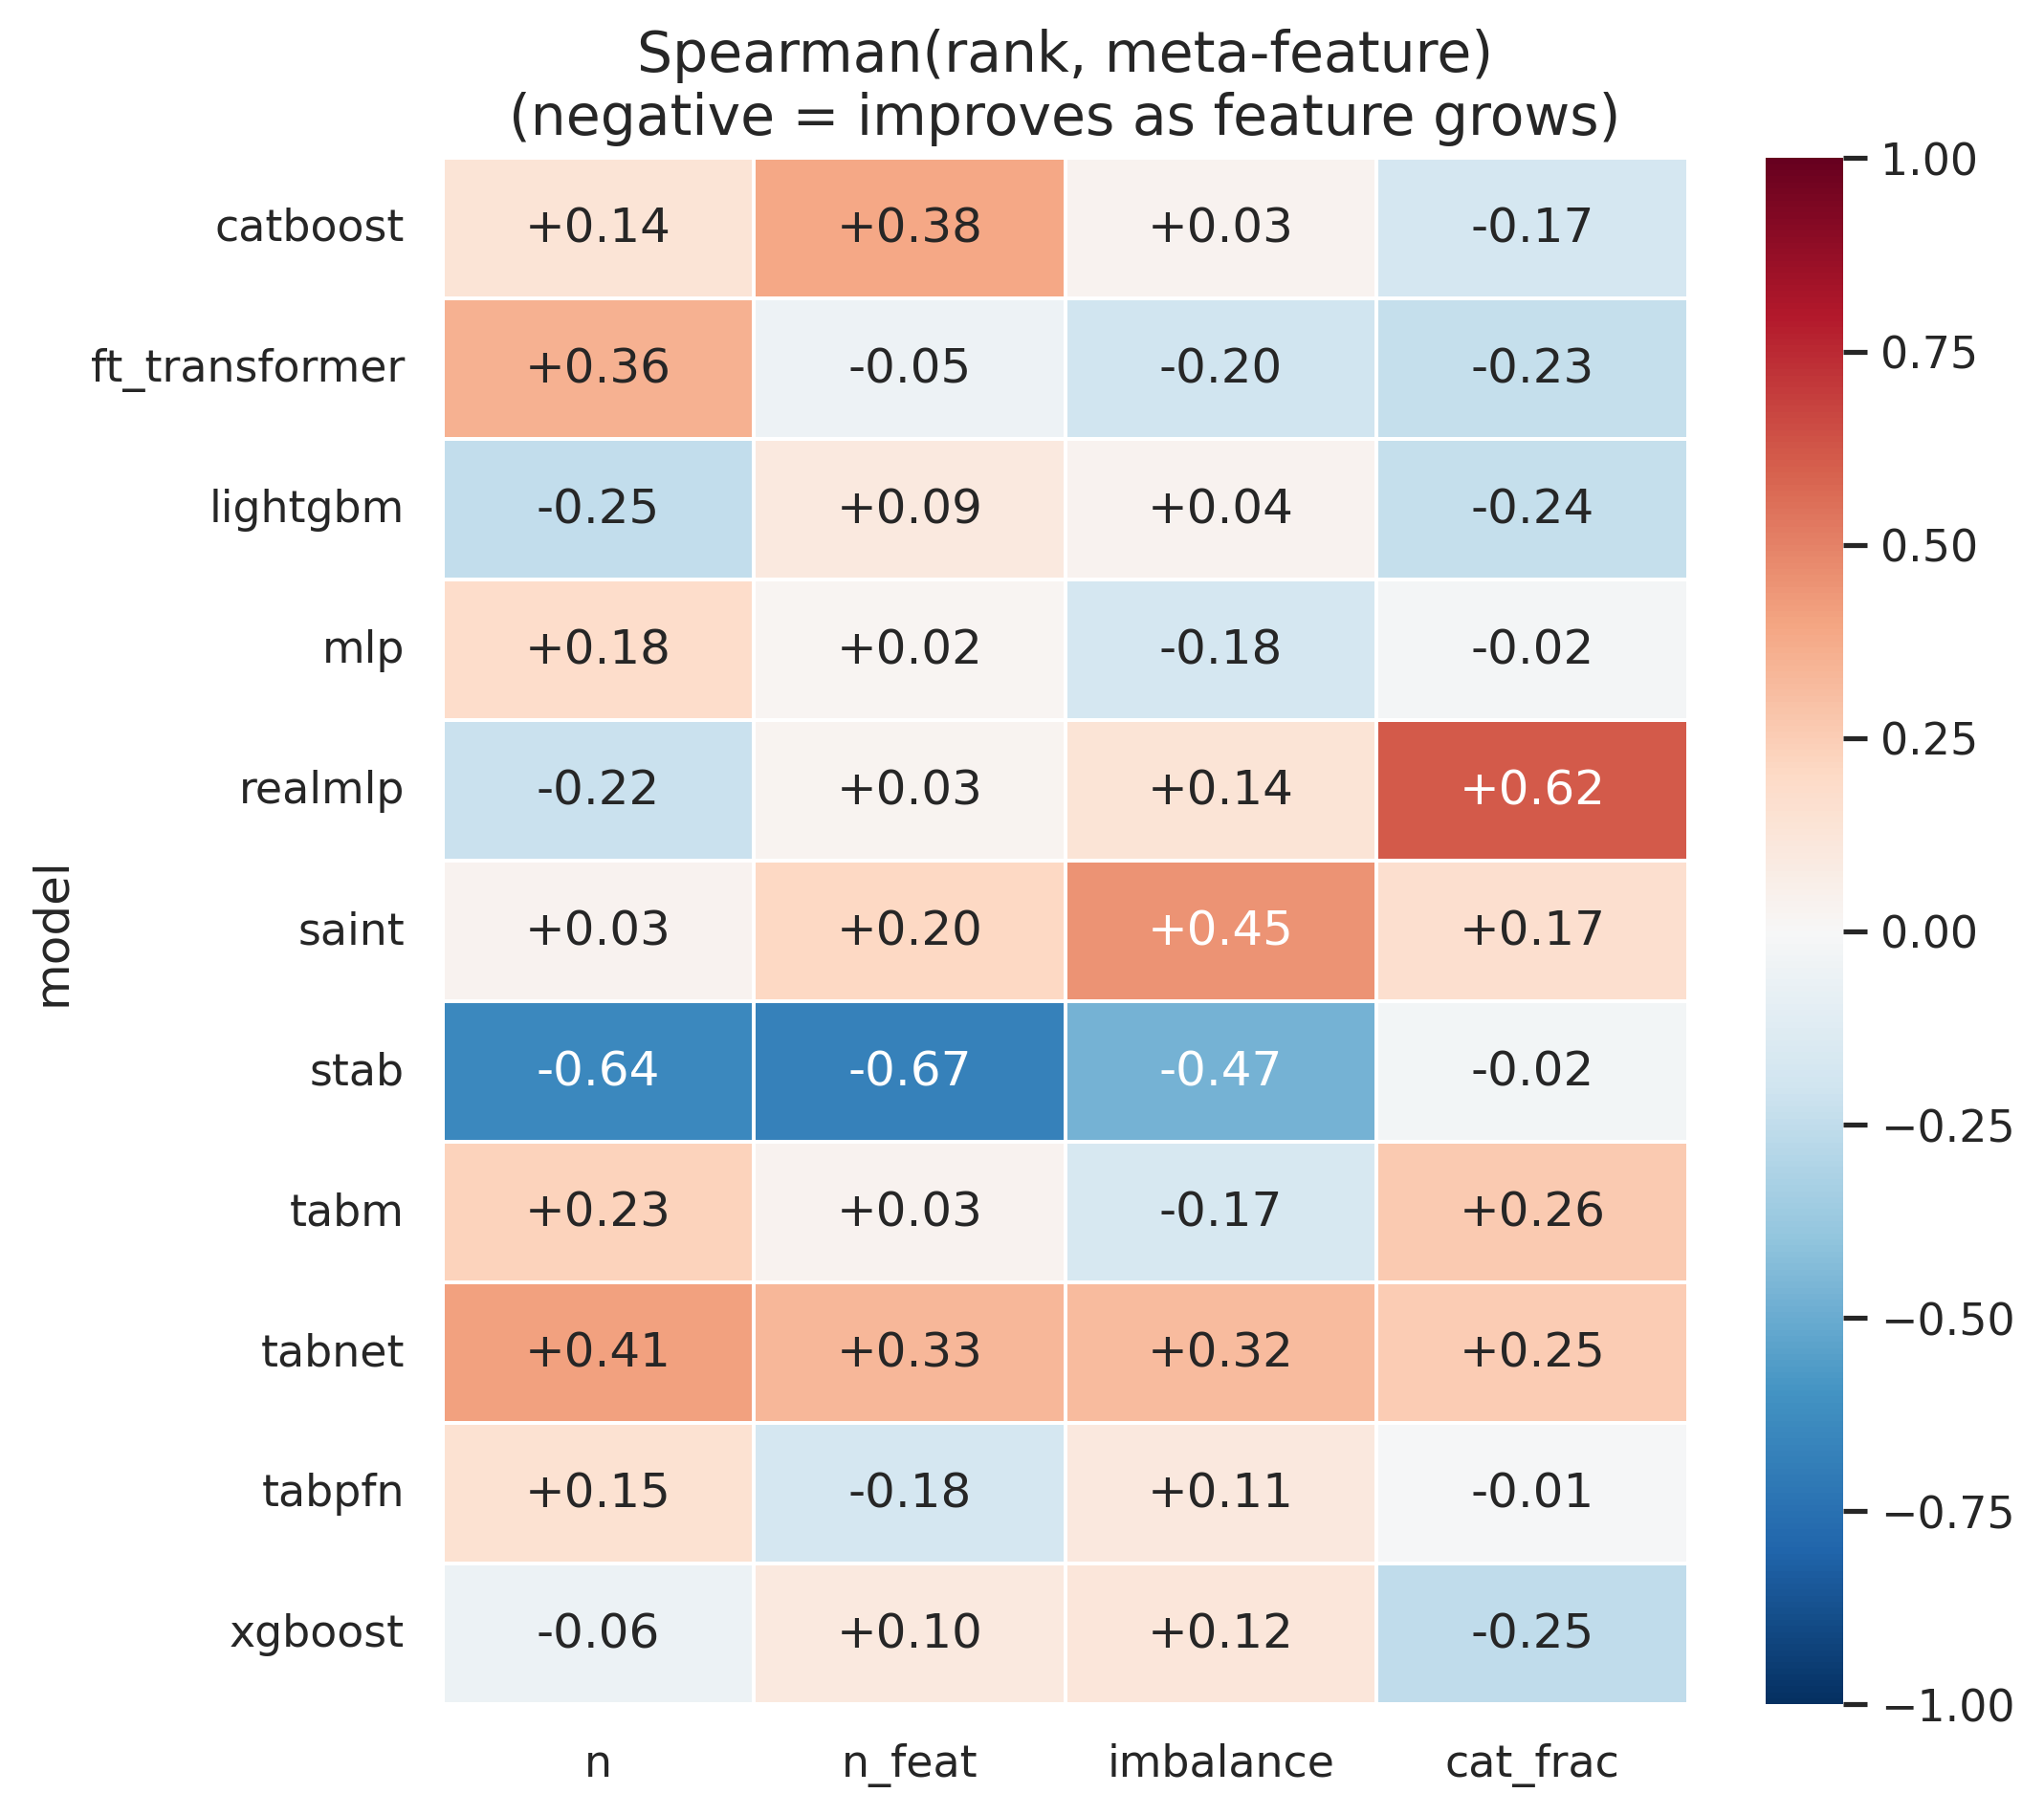

*Correlacao (Spearman) entre o rank de cada modelo e cada meta-feature.*

In [17]:
show('metafeature_correlations.png', 'Correlacao (Spearman) entre o rank de cada modelo e cada meta-feature.', 560)

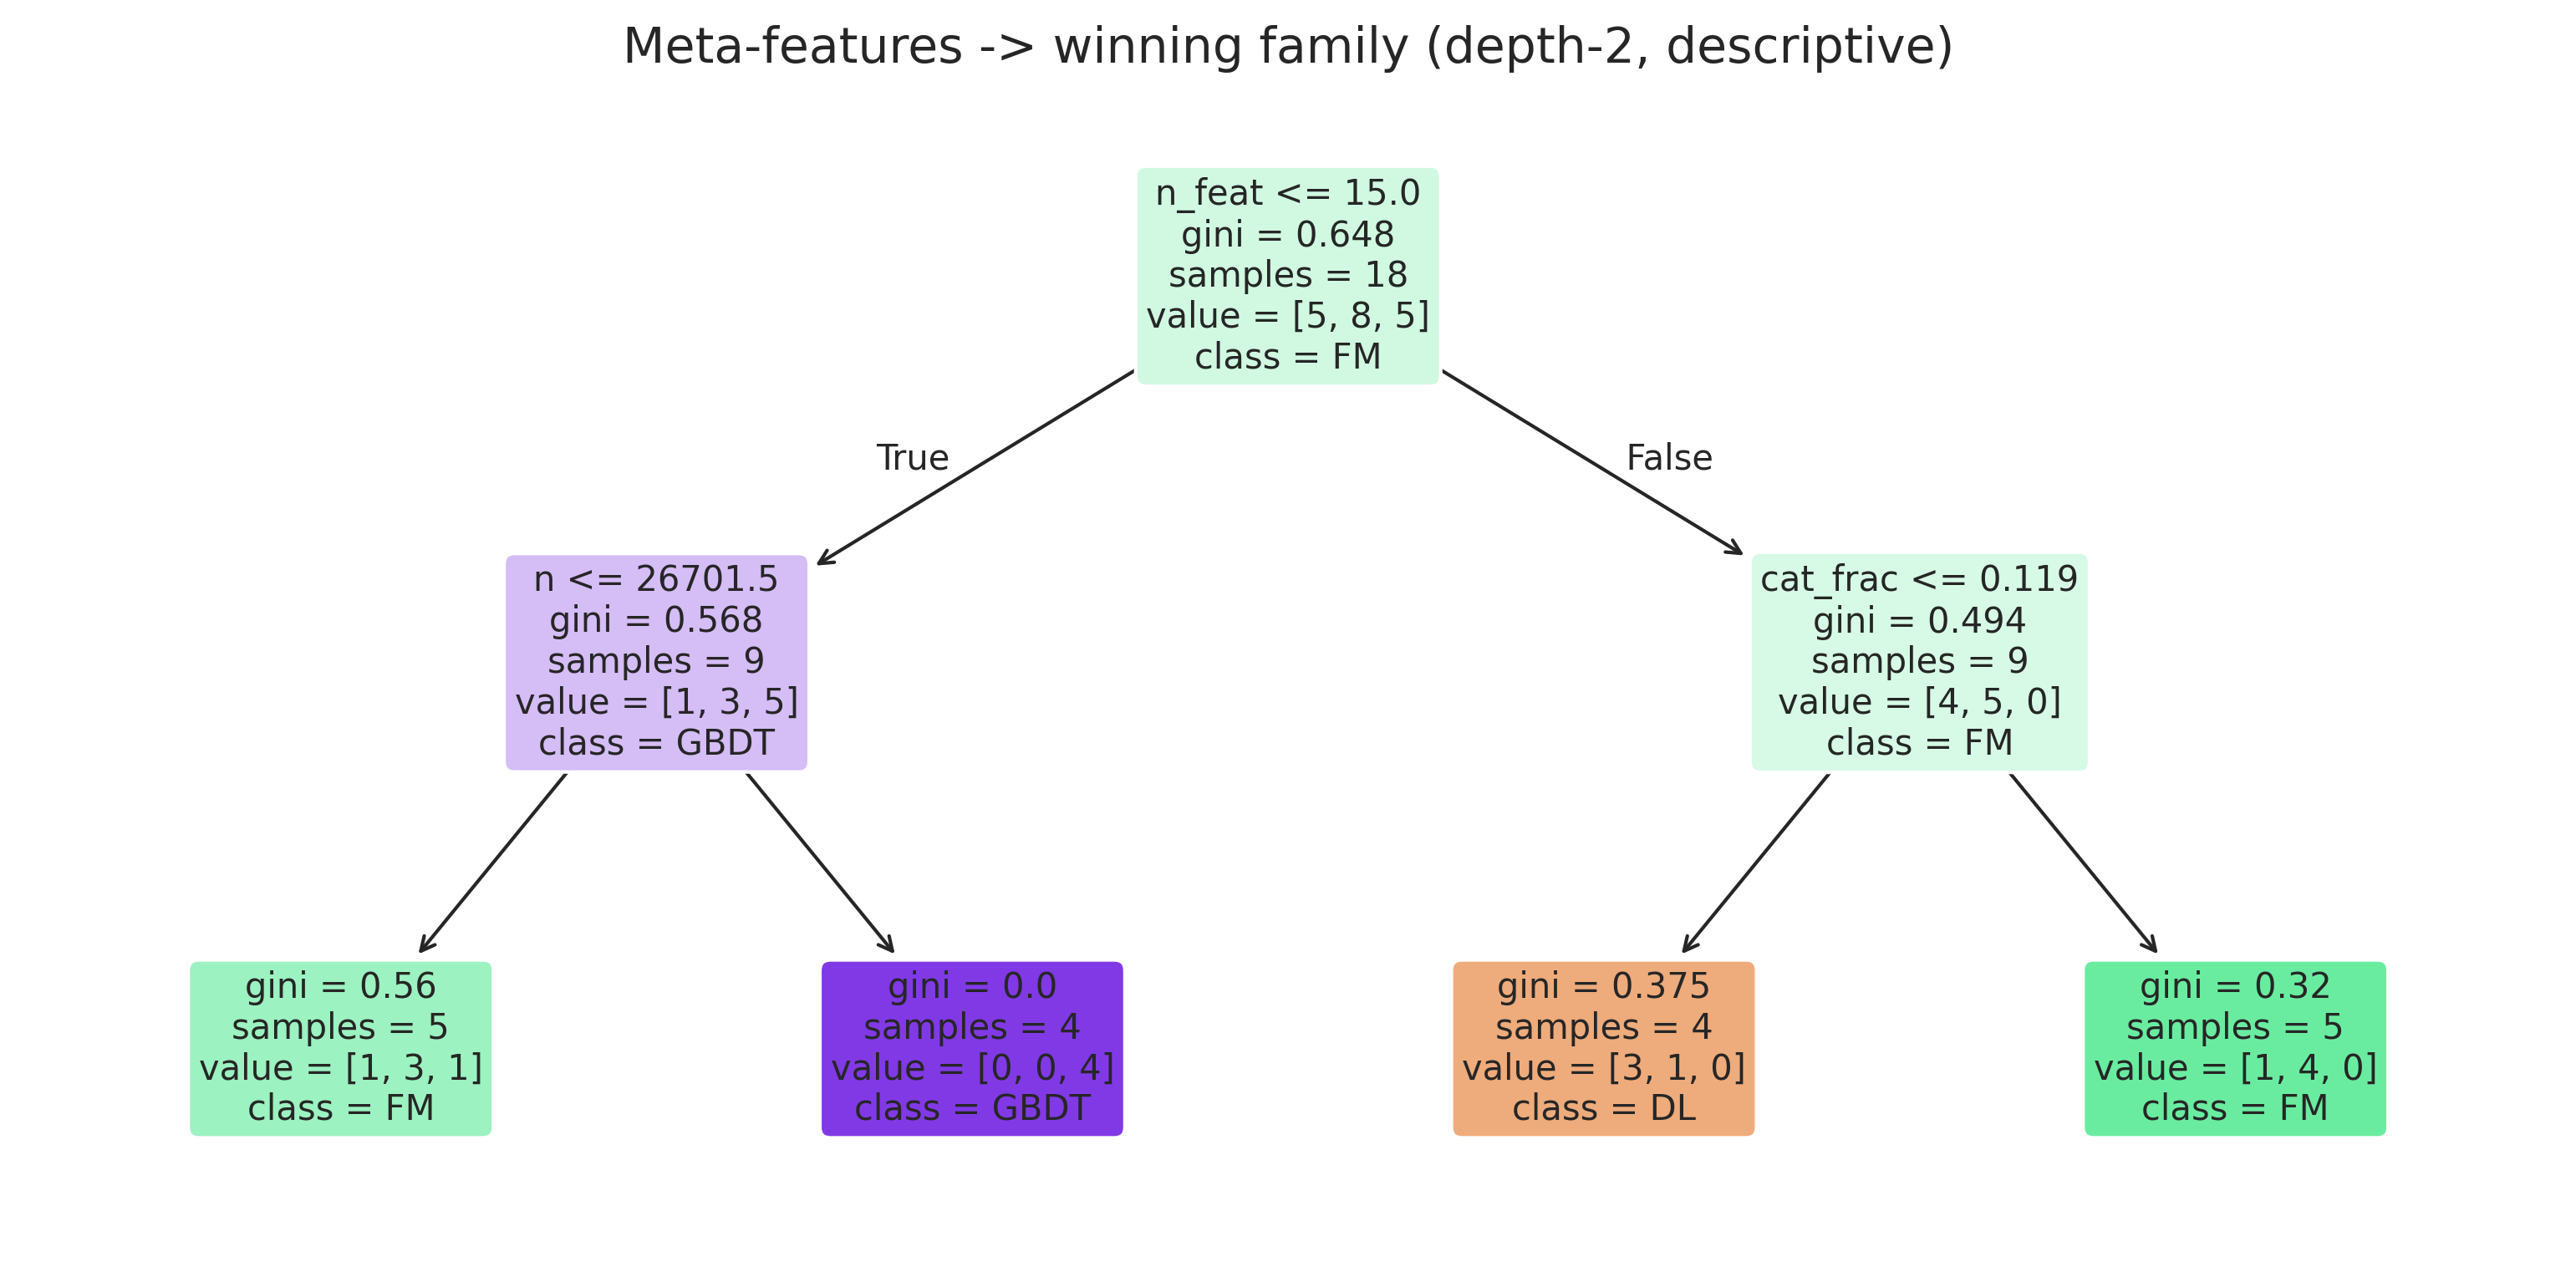

*Arvore meta-features -> familia vencedora: pequeno+poucas features -> TabPFN; grande+poucas -> GBDT; muitas features numericas -> DL.*

In [18]:
show('winner_decision_tree.png', 'Arvore meta-features -> familia vencedora: pequeno+poucas features -> TabPFN; grande+poucas -> GBDT; muitas features numericas -> DL.', 760)

---
## 8. Ato IV — O Framework de Decisão (a contribuição)

Síntese de todos os eixos em **(1)** uma matriz multicritério (pontuada a partir dos dados) e
**(2)** um flowchart prático — inexistente na literatura para o conjunto 2024–2025.

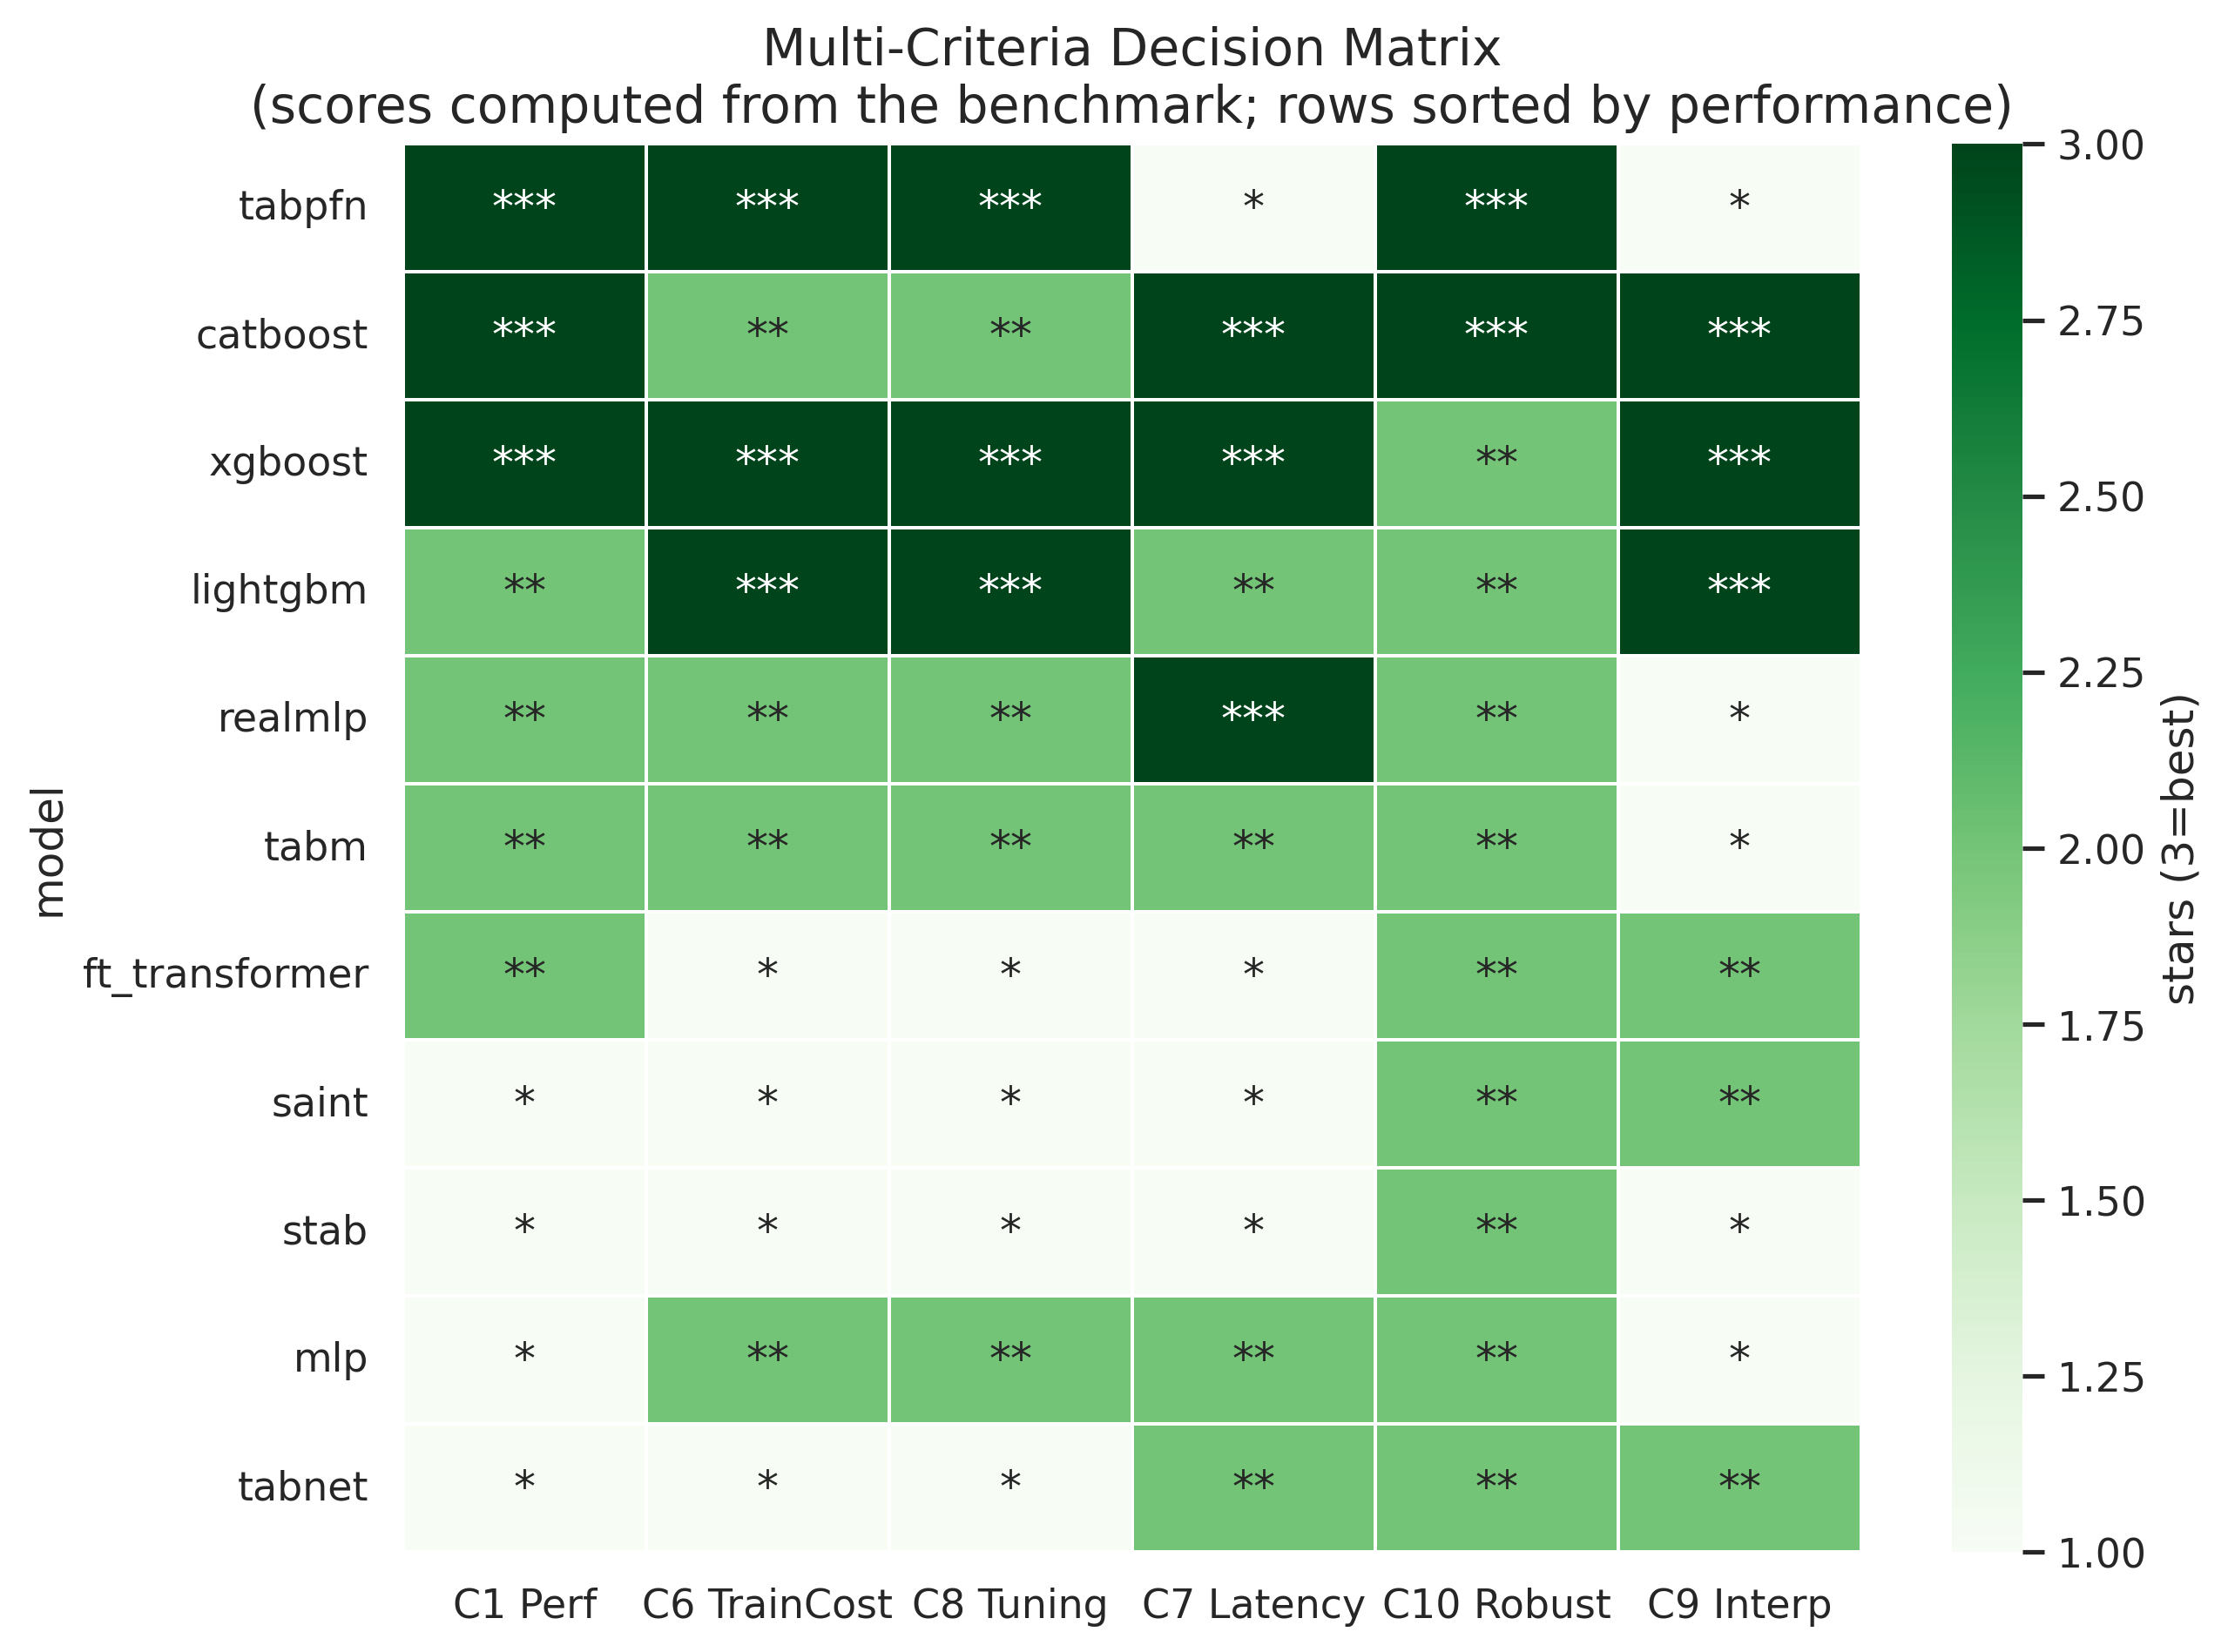

*Matriz de decisao: nenhum modelo e' 3-estrelas em tudo. TabPFN domina perf/tuning/robustez mas e' fraco em latencia; GBDTs sao os all-rounders.*

In [19]:
show('decision_matrix.png', 'Matriz de decisao: nenhum modelo e\' 3-estrelas em tudo. TabPFN domina perf/tuning/robustez mas e\' fraco em latencia; GBDTs sao os all-rounders.', 760)

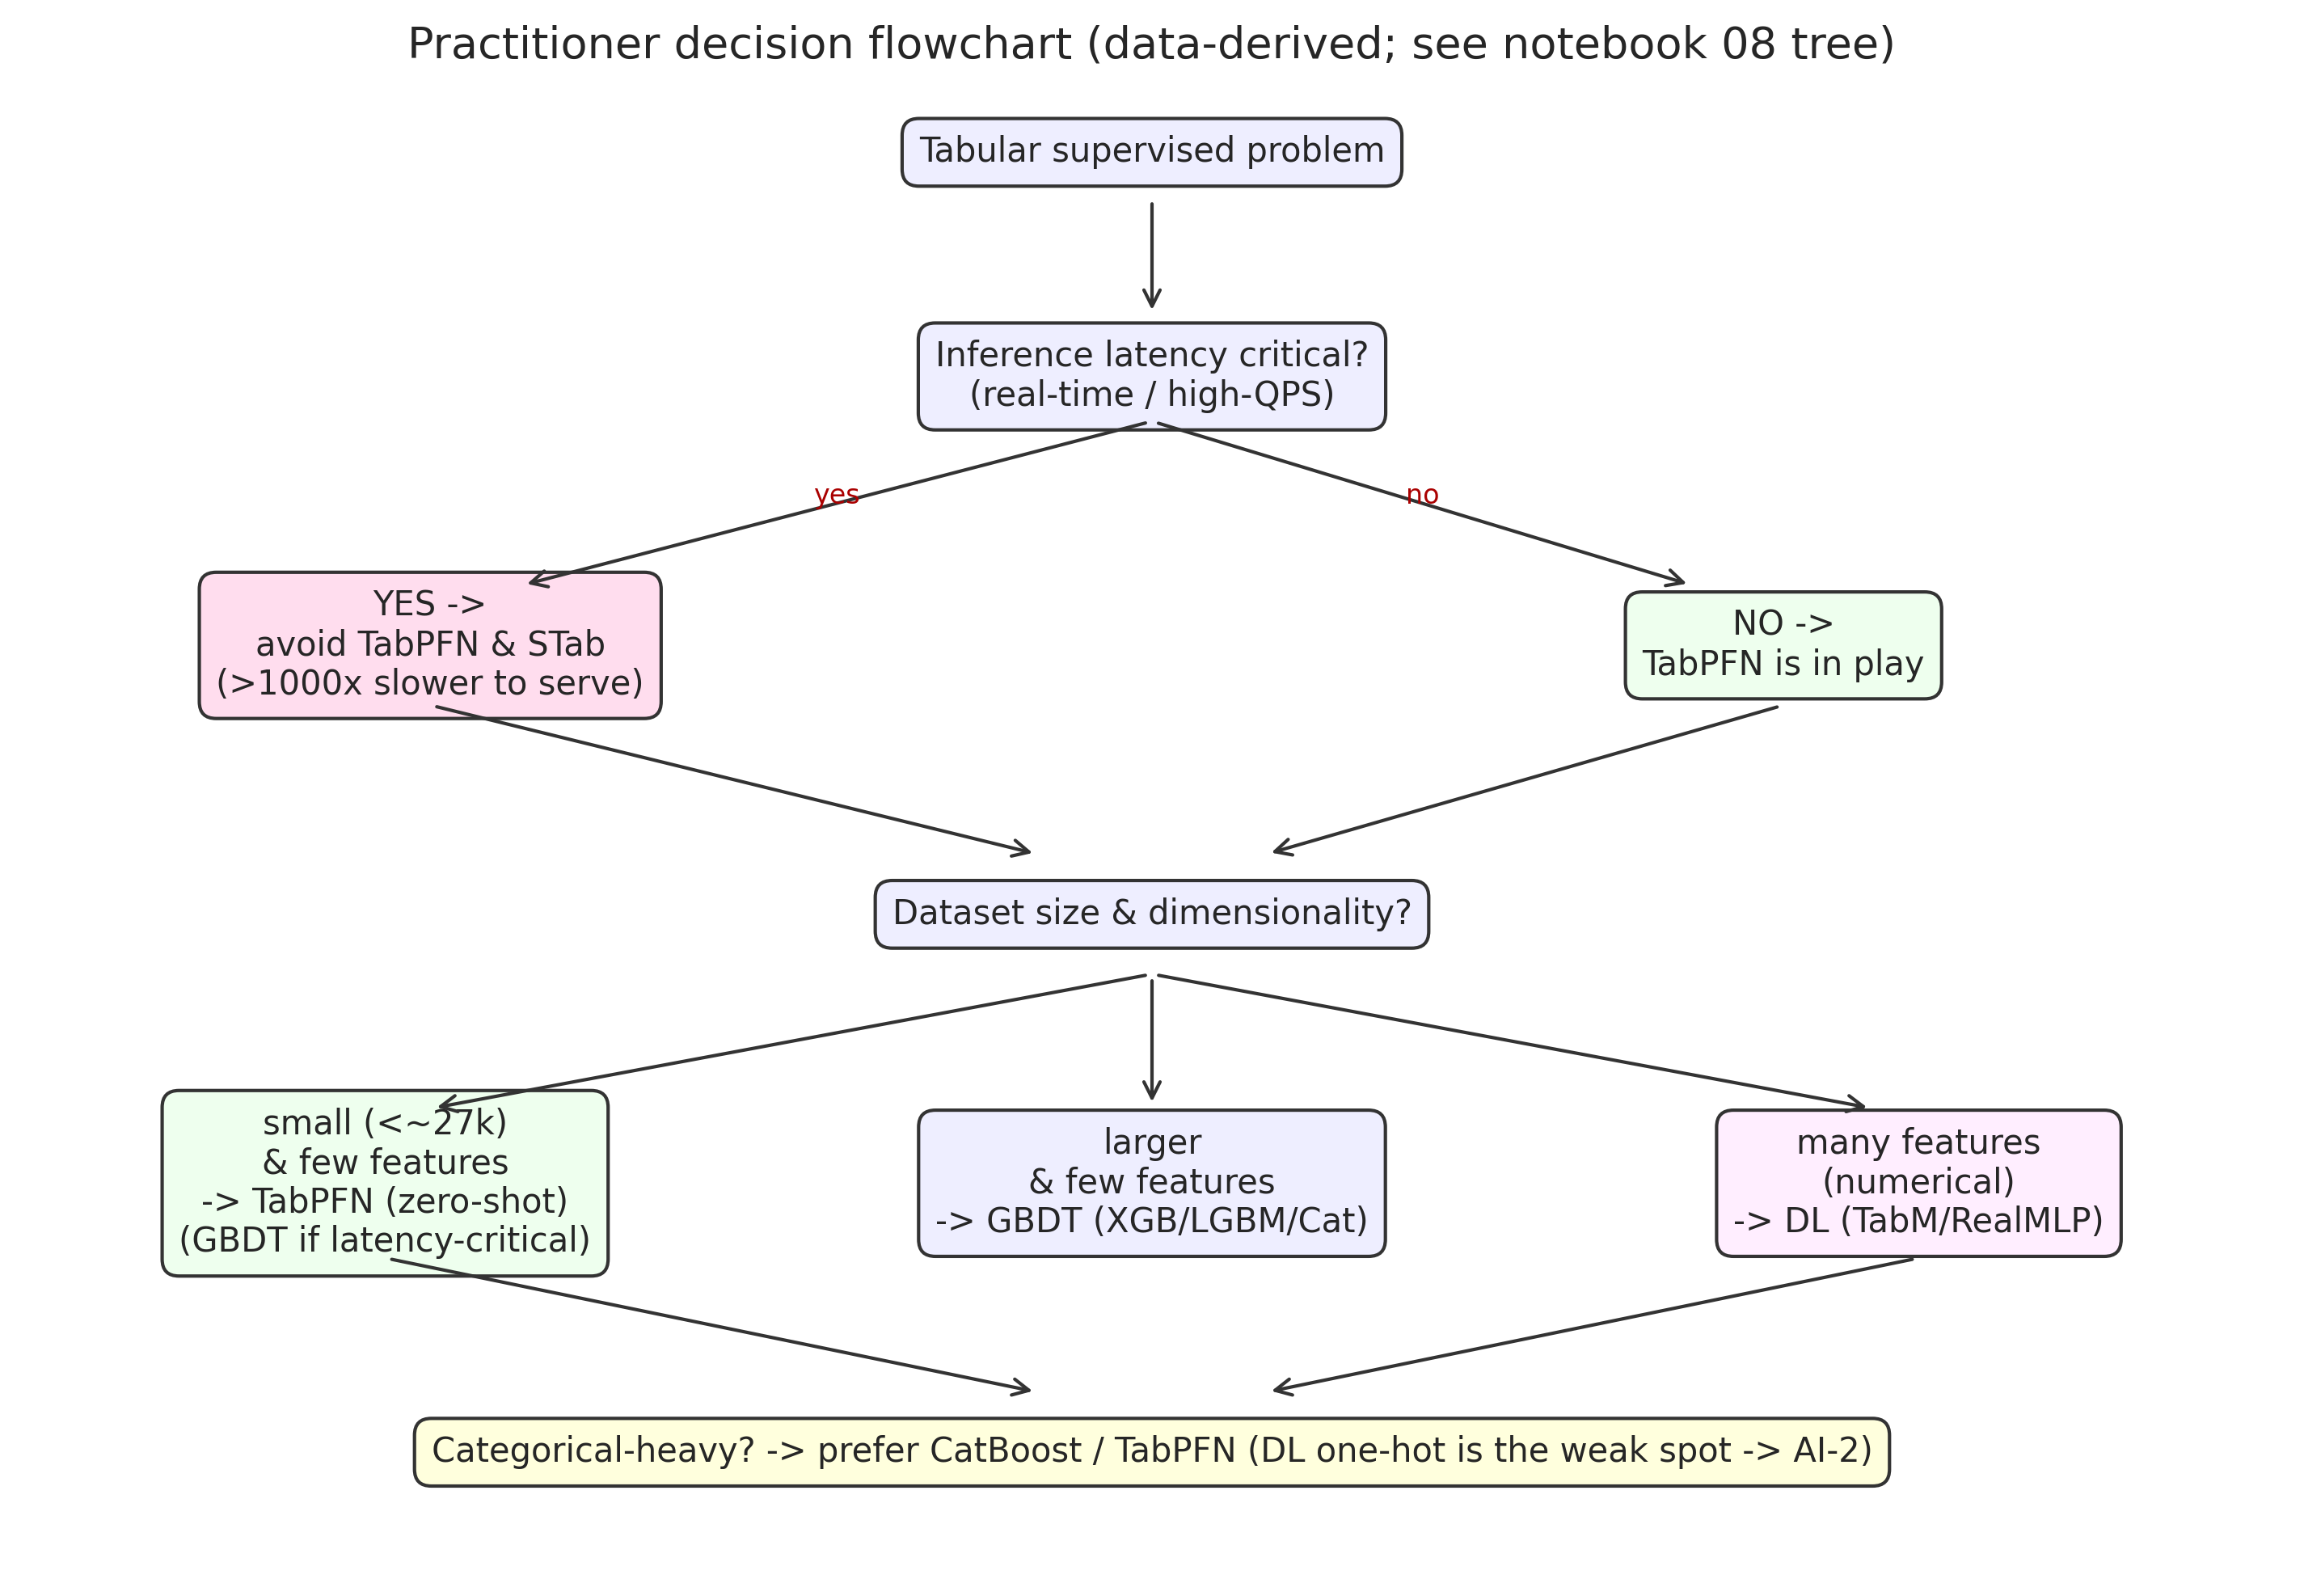

*Flowchart do praticante: responda 3 perguntas (latencia? tamanho/dimensao? categorico?) e obtenha um shortlist defensavel.*

In [20]:
show('decision_flowchart.png', 'Flowchart do praticante: responda 3 perguntas (latencia? tamanho/dimensao? categorico?) e obtenha um shortlist defensavel.', 820)

---
## 9. Interpretabilidade (C9)

GBDTs são intrinsecamente interpretáveis (importância de features, SHAP exato via TreeExplainer);
atenção é parcialmente interpretável; MLP/foundation são caixa-preta (exigem métodos post-hoc).

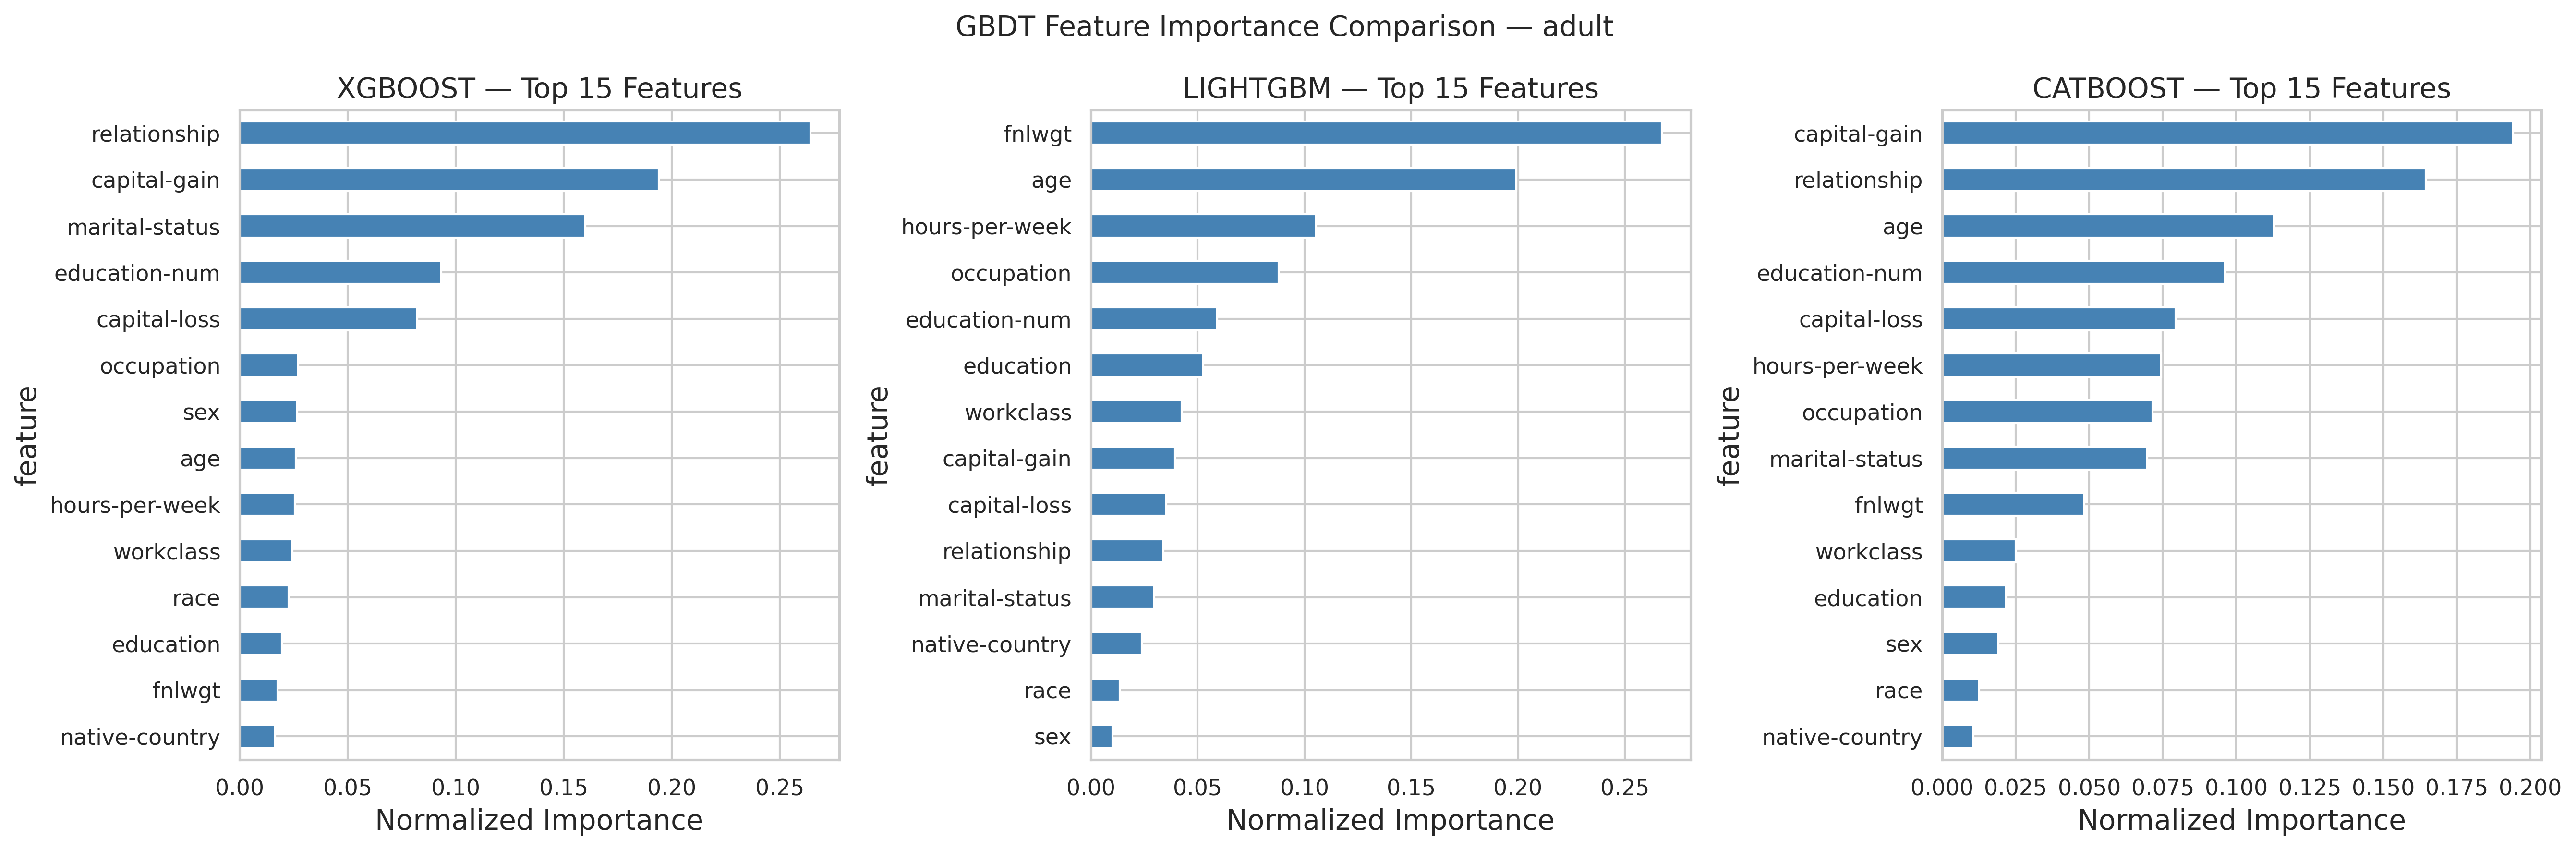

*Importancia de features nos 3 GBDTs (adult) — alta concordancia sobre o que importa.*

In [21]:
show('feature_importance_comparison.png', 'Importancia de features nos 3 GBDTs (adult) — alta concordancia sobre o que importa.', 820)

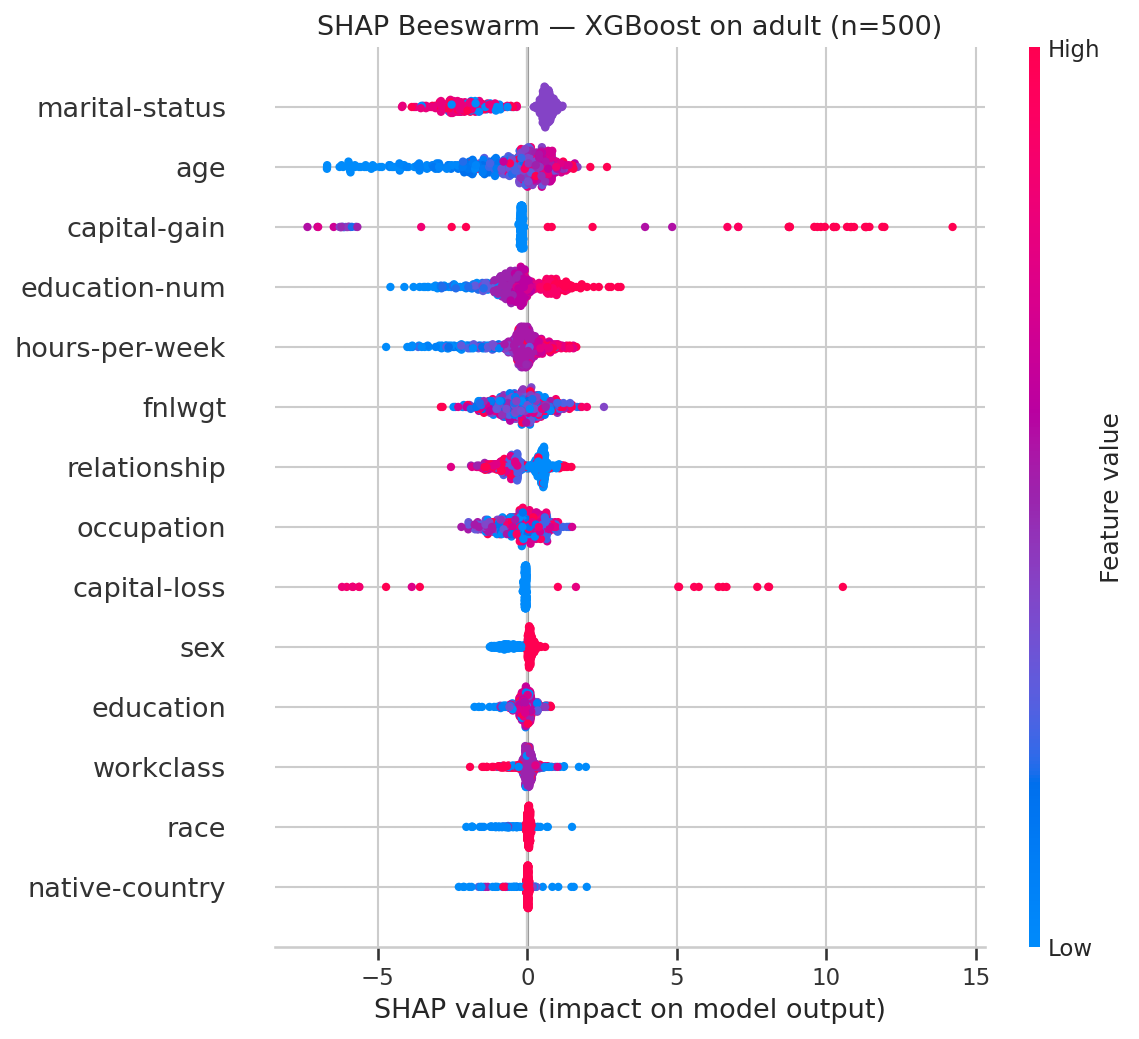

*SHAP (XGBoost, adult): atribuicao por amostra, direcao e magnitude de cada feature.*

In [22]:
show('shap_beeswarm_adult.png', 'SHAP (XGBoost, adult): atribuicao por amostra, direcao e magnitude de cada feature.', 680)

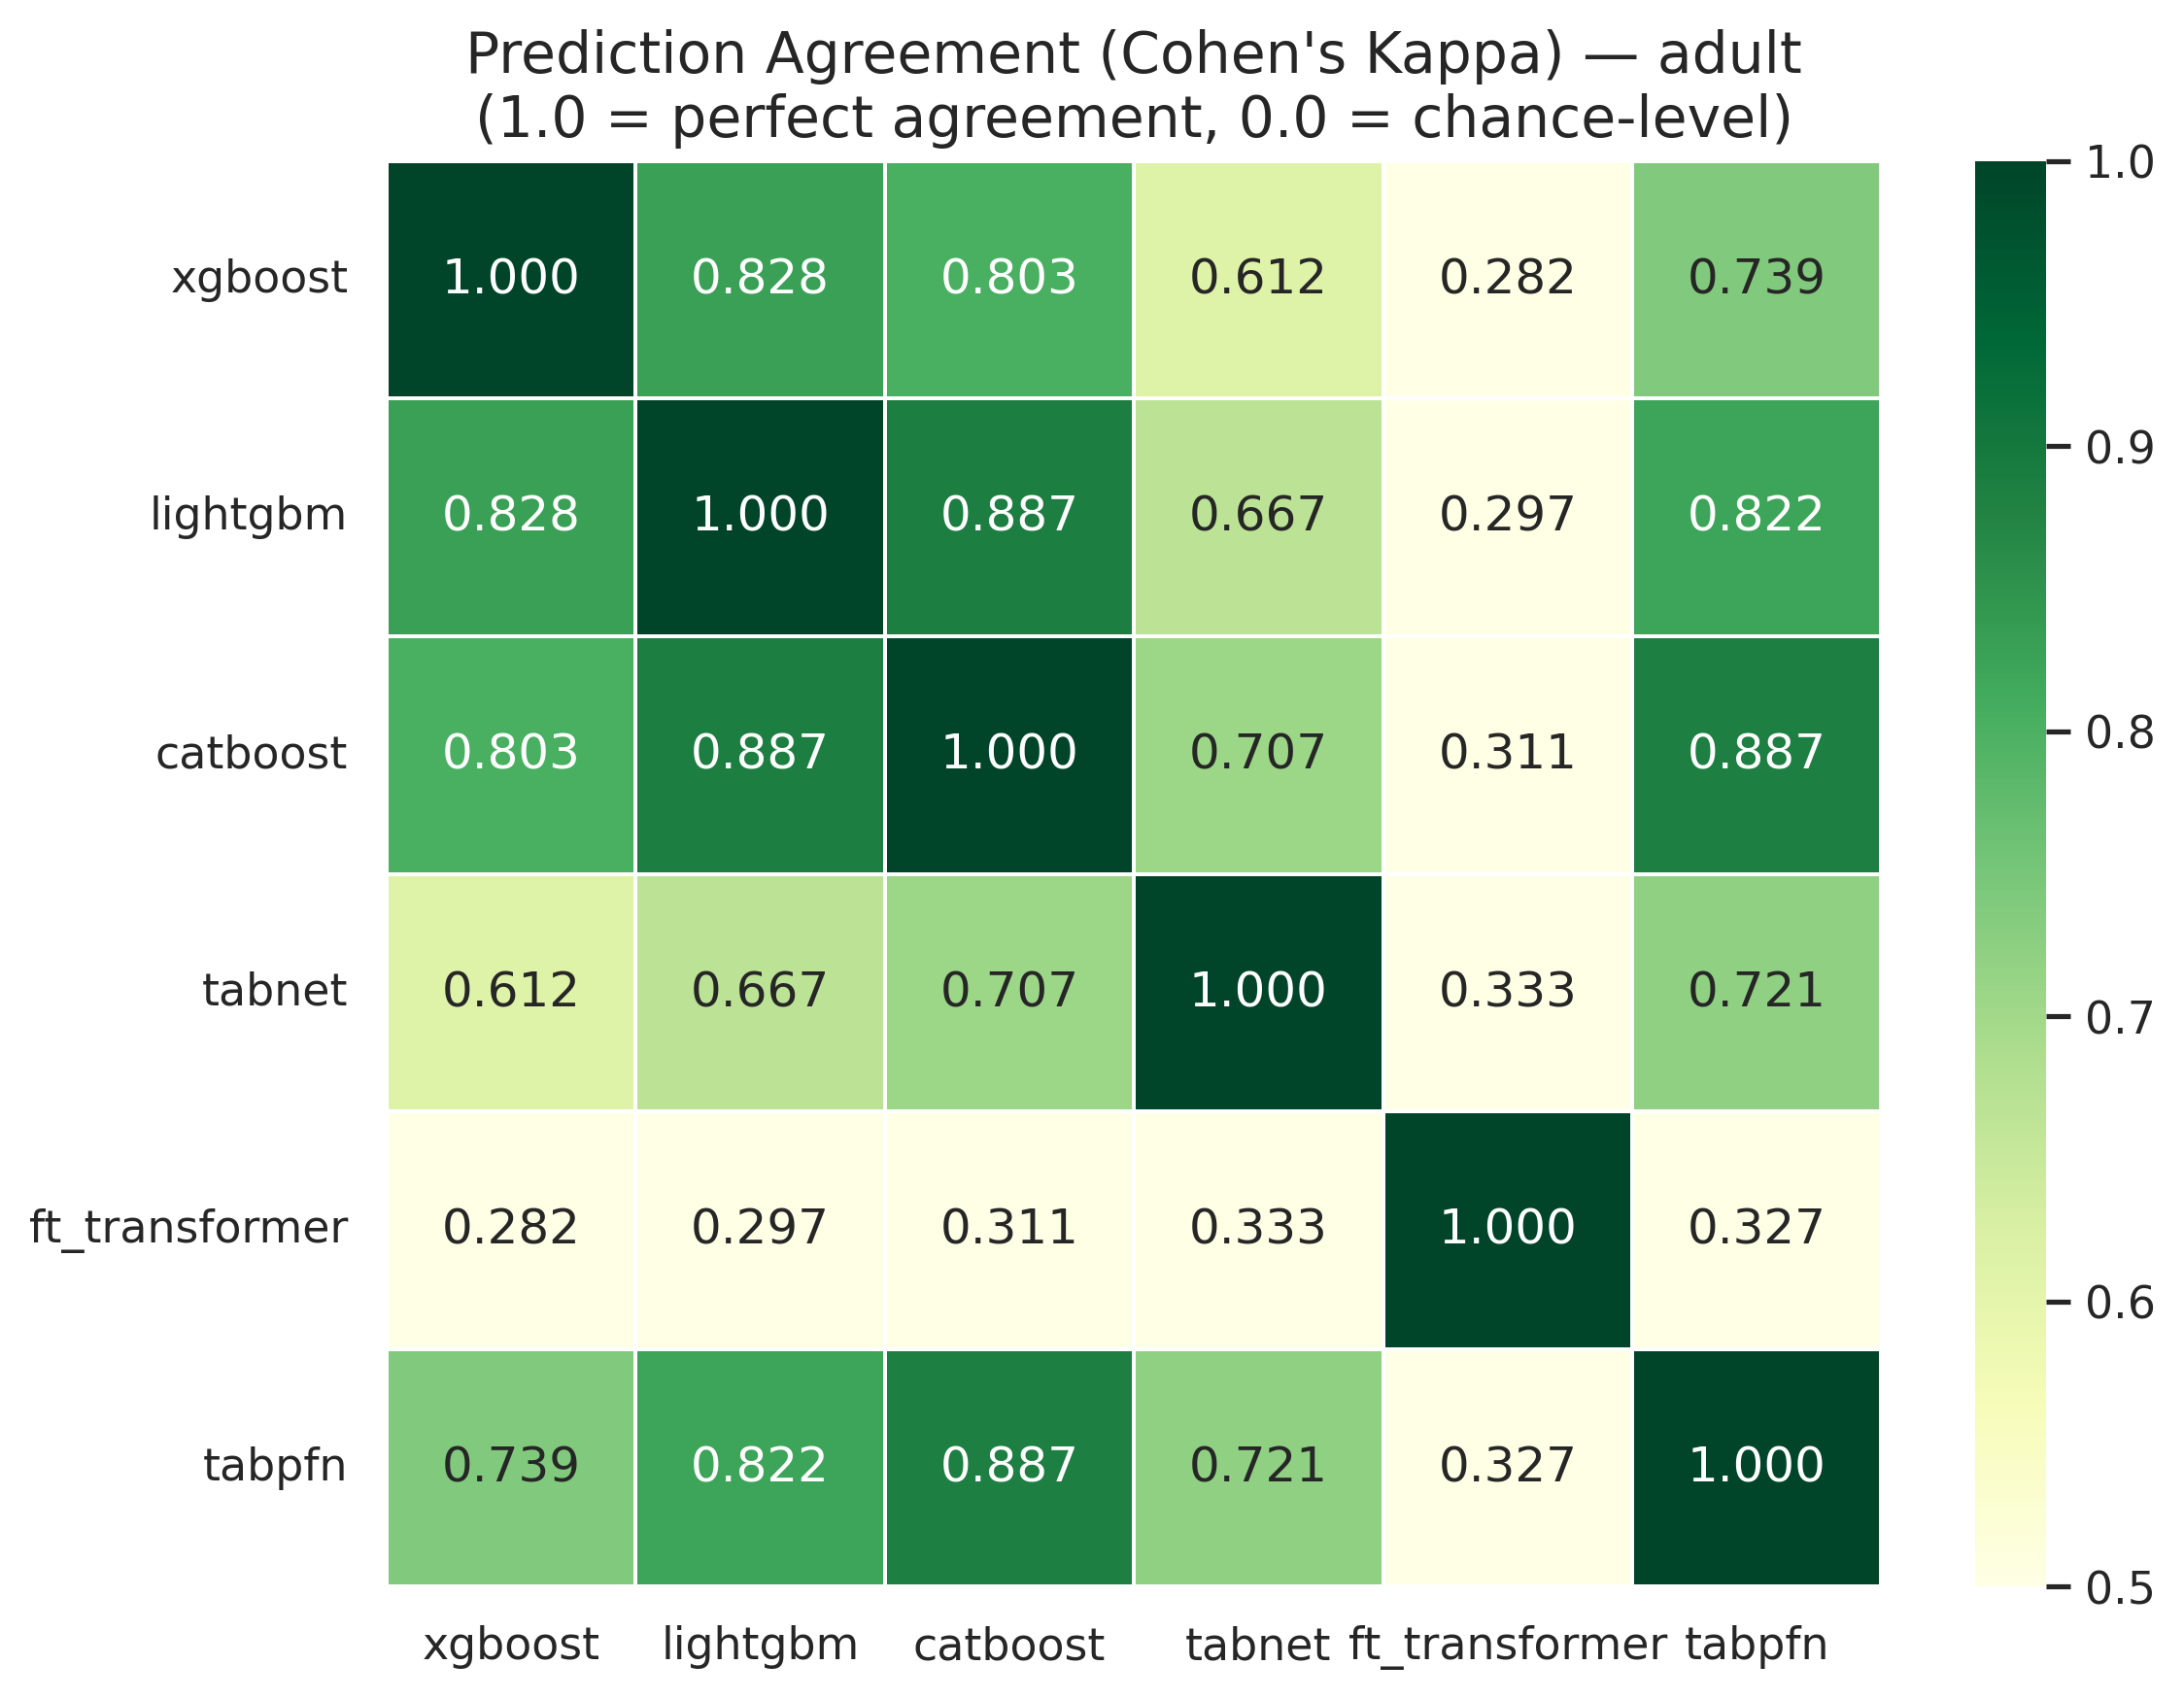

*Concordancia de predicoes (Cohen kappa) entre familias — quanto os modelos capturam padroes diferentes.*

In [23]:
show('prediction_agreement.png', 'Concordancia de predicoes (Cohen kappa) entre familias — quanto os modelos capturam padroes diferentes.', 680)

---
## 10. Honestidade estatística, próximos passos e onde mora a AI-2

**Caveats que carrego no texto:**
- **Baixo poder estatístico** (10/3/5 datasets): Friedman acha diferença, o topo é empate. Não afirmo
  "vencedor único" — uso bayesiano + decomposição de variância para sustentar o empate com rigor.
- **TabPFN em dados grandes** roda em subamostra de 50K; a história real é a competitividade *zero-shot*.
- **Multiclasse é sub-amostrado** (N=3) e TabPFN-incompleto (helena, 100 classes > limite) → descritivo.
- O *bin* severo de desbalanceamento está **confundido** com cardinalidade (amazon_employee).

**Próximo compute (escopado honestamente — sementes de AI-2):**
- **Curvas de aprendizado / crossover (RQ2)** — re-treino por frações {10..100%} para achar o tamanho
  em que o DL alcança o GBDT (exige re-treino; os trials do Optuna não foram persistidos).
- **Sensibilidade ao tuning** — re-rodar com defaults para medir o *valor do tuning* por modelo.

**Onde mora a contribuição (AI-2):** o gargalo mais concreto e acionável é o **encoding categórico do DL**
(explosão de one-hot → OOM/degradação dos modelos de atenção em `amazon_employee`). Um pipeline de
**embeddings aprendidos / target encoding** que feche a distância DL–GBDT em dados categóricos é uma
contribuição validável, semeada diretamente por este benchmark.

---
### Reprodutibilidade
seed=42 fixo · hash SHA-256 de cada dataset gravado por experimento · configs versionadas
(`configs/*.yaml`) · 197/198 resultados + notebooks executados no GitHub. Análises sofisticadas em
`src/evaluation/enrichments.py`; narrativa completa em `docs/00-analysis-narrative.md`.